# MIT RF Challenge: Data Analysis

### Introduction

This project studies whether multivariate statistical features extracted from radio-frequency (RF) mixture signals can distinguish signal classes in the MIT RF Challenge preliminary dataset. In RF signal analysis, the observed waveform is naturally multivariate in the sense that each example contains rich joint structure across amplitude, phase, and spectral behavior. Rather than treating the problem purely as an engineering task of demodulation or source separation, the goal here is to examine what standard methods from multivariate statistics reveal about the geometry, density structure, and class separability of these signals.

The dataset considered here consists of 9,900 mixture signals drawn evenly from three classes: CommSignal2, CommSignal3, and EMISignal1. Each observation is a complex IQ waveform represented in SigMF format. From each waveform, I constructed a set of summary features describing signal amplitude, variability, peak-to-average behavior, phase dispersion, and spectral structure. These features transform each raw signal into a multivariate feature vector suitable for statistical analysis.

The main research question is: to what extent can waveform-derived summary features distinguish RF signal classes, and what linear and nonlinear low-dimensional representations reveal that class structure? To answer this question, I used principal component analysis (PCA) to study major directions of variation, kernel density estimation (KDE) to compare class-conditional feature distributions, linear and quadratic discriminant analysis (LDA/QDA) as supervised classification methods, and cross-validation to assess predictive performance. I also used UMAP and t-SNE as exploratory nonlinear embedding methods to visualize latent geometric structure in the feature space.

A key modeling issue in this dataset is that center frequency is highly informative of class membership. Indeed, including center frequency as a predictor yielded perfect cross-validated classification accuracy. Because this risks trivializing the classification problem, the primary analysis focuses on waveform-derived features excluding center frequency, with the frequency-inclusive model treated as a benchmark rather than the main scientific result.

The results show that the signal classes are substantially distinguishable from waveform statistics alone. Spectral flatness, spectral entropy, and peak-to-average power ratio emerge as especially informative features, while PCA and nonlinear embeddings reveal both class separation and within-class substructure. These findings illustrate how multivariate statistical methods can provide interpretable insight into RF mixture data beyond purely black-box predictive modeling.

### Methods
### Data

The analysis used the demod_train portion of the MIT RF Challenge preliminary release. I restricted attention to mixture signals from three balanced classes: CommSignal2, CommSignal3, and EMISignal1, with 3,300 observations per class for a total of 9,900 signals. Each signal was stored in SigMF format as a complex baseband IQ waveform with 40,960 complex samples and a sample rate of 25 MHz.

### Feature Construction

Each waveform was converted into a multivariate feature vector using summary statistics designed to capture amplitude, phase, and spectral characteristics. The features included:

RMS power
mean amplitude
amplitude standard deviation
maximum amplitude
peak-to-average power ratio (PAPR)
mean and standard deviation of the real and imaginary parts
skewness and kurtosis of the magnitude
phase standard deviation
spectral centroid
spectral flatness
spectral entropy

These features were chosen because they provide interpretable summaries of signal strength, dispersion, peakiness, and spectral complexity.

Although center frequency was available in the metadata, it was excluded from the primary analyses because it produced perfect classification accuracy and therefore obscured the more interesting question of whether waveform structure alone distinguishes the classes.

### Principal Component Analysis

I applied PCA to the standardized feature matrix in order to identify the dominant linear directions of variation in the data. Standardization was necessary because the features were measured on different scales. PCA was used both for interpretation of the main variance directions through loading vectors and for visualization of the observations in the first two principal component coordinates.

### Kernel density estimation

To study class-conditional distributional differences, I used kernel density estimation on several especially informative scalar features, including spectral entropy, spectral flatness, PAPR, and magnitude kurtosis. These density plots were used to assess how strongly the classes differed along individual waveform-derived characteristics.

### Classification methods

I compared three supervised classification methods:

Linear Discriminant Analysis (LDA)
Quadratic Discriminant Analysis (QDA)
Multinomial logistic regression

LDA assumes a common covariance structure across classes and produces linear decision boundaries. QDA relaxes this assumption by allowing each class to have its own covariance matrix, leading to quadratic decision boundaries. Multinomial logistic regression provides a linear probabilistic baseline without the Gaussian class-conditional assumptions used by LDA and QDA.

### Model Assessment

Predictive performance was evaluated using 5-fold stratified cross-validation, with classification accuracy as the main assessment metric. I also examined the cross-validated confusion matrix for LDA to identify which class pairs were most frequently confused.

### Nonlinear Visualization

To complement PCA, I used t-SNE and UMAP on PCA-reduced standardized features. These methods were used only for exploratory visualization of possible nonlinear structure and within-class subgroups; they were not treated as inferential or predictive methods.

In [103]:
# Imports for the notebook
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from scipy.stats import kurtosis, skew, entropy
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [104]:
# Load Data
root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train")

print("Root exists:", root.exists())

all_data_files = list(root.rglob("*.sigmf-data"))
print("Number of .sigmf-data files found:", len(all_data_files))
print("First few files:")
for f in all_data_files[:10]:
    print("  ", f)

def first_or_empty(lst):
    return lst[0] if isinstance(lst, list) and len(lst) > 0 else {}

Root exists: True
Number of .sigmf-data files found: 9900
First few files:
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0000.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0001.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0002.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0003.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0004.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0005.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0006.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0007.sigmf-data
   D:

In [105]:
def load_sigmf_pair(data_path):
    meta_path = data_path.with_suffix(".sigmf-meta")

    with open(meta_path, "r") as f:
        meta = json.load(f)

    raw = np.fromfile(data_path, dtype="<f4")

    # interleaved float32 IQ: I0,Q0,I1,Q1,...
    if len(raw) % 2 != 0:
        raise ValueError(f"Odd number of float32 values in {data_path}")

    x = raw[0::2] + 1j * raw[1::2]
    return x.astype(np.complex64), meta

def first_or_empty(lst):
    return lst[0] if isinstance(lst, list) and len(lst) > 0 else {}

def infer_labels(path):
    name = path.name

    if "CommSignal2" in name:
        base_class = "CommSignal2"
    elif "CommSignal3" in name:
        base_class = "CommSignal3"
    elif "EMISignal1" in name or "EmiSignal1" in name:
        base_class = "EMISignal1"
    else:
        base_class = "unknown"

    if "(1)" in name:
        kind = "component"
    elif "(2)" in name:
        kind = "bits_ref"
    else:
        kind = "mixture"

    return base_class, kind

def extract_features(x):
    mag = np.abs(x)
    ph = np.angle(x)

    Xf = np.fft.fftshift(np.fft.fft(x))
    psd = np.abs(Xf) ** 2
    psd_sum = psd.sum()
    psd_norm = psd / psd_sum if psd_sum > 0 else np.ones_like(psd) / len(psd)

    freqs = np.linspace(-0.5, 0.5, len(x), endpoint=False)

    return {
        "n_samples": len(x),
        "rms_power": float(np.mean(mag**2)),
        "amp_mean": float(np.mean(mag)),
        "amp_std": float(np.std(mag)),
        "amp_max": float(np.max(mag)),
        "papr": float(np.max(mag**2) / (np.mean(mag**2) + 1e-12)),
        "real_mean": float(np.mean(np.real(x))),
        "imag_mean": float(np.mean(np.imag(x))),
        "real_std": float(np.std(np.real(x))),
        "imag_std": float(np.std(np.imag(x))),
        "mag_skew": float(skew(mag)),
        "mag_kurt": float(kurtosis(mag, fisher=False)),
        "phase_std": float(np.std(ph)),
        "spec_centroid": float(np.sum(freqs * psd_norm)),
        "spec_flatness": float(np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)),
        "spec_entropy": float(entropy(psd_norm + 1e-12)),
    }

rows = []
data_files = list(root.rglob("*.sigmf-data"))

print(f"Found {len(data_files)} signal files")

for i, data_path in enumerate(data_files):
    try:
        x, meta = load_sigmf_pair(data_path)
        base_class, kind = infer_labels(data_path)

        global_meta = meta.get("global", {})
        capture0 = first_or_empty(meta.get("captures", []))
        annotation0 = first_or_empty(meta.get("annotations", []))

        row = {
            "filename": data_path.name,
            "relative_path": str(data_path.relative_to(root)),
            "base_class": base_class,
            "kind": kind,
            "sample_rate": global_meta.get("core:sample_rate"),
            "center_freq": capture0.get("core:frequency"),
            "description": annotation0.get("core:description"),
        }

        row.update(extract_features(x))
        rows.append(row)

        if i < 3:
            print("Loaded OK:", data_path.name)
            print("  captures len:", len(meta.get("captures", [])))
            print("  annotations len:", len(meta.get("annotations", [])))

    except Exception as e:
        print(f"Error with {data_path}: {e}")

df = pd.DataFrame(rows)
print("Final dataframe shape:", df.shape)
print(df.head())

df.to_csv("demod_train_features.csv", index=False)

Found 9900 signal files
Loaded OK: CommSignal2_demod_train_0000.sigmf-data
  captures len: 1
  annotations len: 0
Loaded OK: CommSignal2_demod_train_0001.sigmf-data
  captures len: 1
  annotations len: 0
Loaded OK: CommSignal2_demod_train_0002.sigmf-data
  captures len: 1
  annotations len: 0
Final dataframe shape: (9900, 23)
                                  filename  \
0  CommSignal2_demod_train_0000.sigmf-data   
1  CommSignal2_demod_train_0001.sigmf-data   
2  CommSignal2_demod_train_0002.sigmf-data   
3  CommSignal2_demod_train_0003.sigmf-data   
4  CommSignal2_demod_train_0004.sigmf-data   

                                       relative_path   base_class     kind  \
0  CommSignal2\CommSignal2_demod_train_0000.sigmf...  CommSignal2  mixture   
1  CommSignal2\CommSignal2_demod_train_0001.sigmf...  CommSignal2  mixture   
2  CommSignal2\CommSignal2_demod_train_0002.sigmf...  CommSignal2  mixture   
3  CommSignal2\CommSignal2_demod_train_0003.sigmf...  CommSignal2  mixture   
4  Co

In [106]:
first_20_data_files = list(root.rglob("*.sigmf-data"))[:20]

In [107]:
print(df.shape)
print(df[["filename", "base_class", "kind", "sample_rate", "center_freq", "description"]].head())

print(df["base_class"].value_counts())
print(df["kind"].value_counts())
print(df.groupby(["base_class", "kind"]).size())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)
print(df[numeric_cols].describe().T)

(9900, 23)
                                  filename   base_class     kind  sample_rate  \
0  CommSignal2_demod_train_0000.sigmf-data  CommSignal2  mixture   25000000.0   
1  CommSignal2_demod_train_0001.sigmf-data  CommSignal2  mixture   25000000.0   
2  CommSignal2_demod_train_0002.sigmf-data  CommSignal2  mixture   25000000.0   
3  CommSignal2_demod_train_0003.sigmf-data  CommSignal2  mixture   25000000.0   
4  CommSignal2_demod_train_0004.sigmf-data  CommSignal2  mixture   25000000.0   

    center_freq description  
0  2.437000e+09        None  
1  2.437000e+09        None  
2  2.437000e+09        None  
3  2.437000e+09        None  
4  2.437000e+09        None  
base_class
CommSignal2    3300
CommSignal3    3300
EMISignal1     3300
Name: count, dtype: int64
kind
mixture    9900
Name: count, dtype: int64
base_class   kind   
CommSignal2  mixture    3300
CommSignal3  mixture    3300
EMISignal1   mixture    3300
dtype: int64
['sample_rate', 'center_freq', 'n_samples', 'rms_power', 

In [108]:
feature_cols_no_cf = [
    "rms_power",
    "amp_mean",
    "amp_std",
    "amp_max",
    "papr",
    "real_mean",
    "imag_mean",
    "real_std",
    "imag_std",
    "mag_skew",
    "mag_kurt",
    "phase_std",
    "spec_centroid",
    "spec_flatness",
    "spec_entropy",
]

feature_cols_with_cf = ["center_freq"] + feature_cols_no_cf

# Part A: Exploratory Signal Geometry

Q: Do different signal/interference types occupy different regions in feature space? Do mixtures vs. components look separable geometrically?

* PCA
* t-SNE
* UMAP

PCA

In [109]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("First 10 explained variance ratios:")
print(explained[:10])
print("Cumulative:")
print(np.cumsum(explained[:10]))

First 10 explained variance ratios:
[0.47554726 0.15125633 0.10030527 0.08472127 0.06615055 0.06385138
 0.02229126 0.01422064 0.01008922 0.00598892]
Cumulative:
[0.47554726 0.62680359 0.72710886 0.81183013 0.87798068 0.94183206
 0.96412332 0.97834396 0.98843318 0.9944221 ]


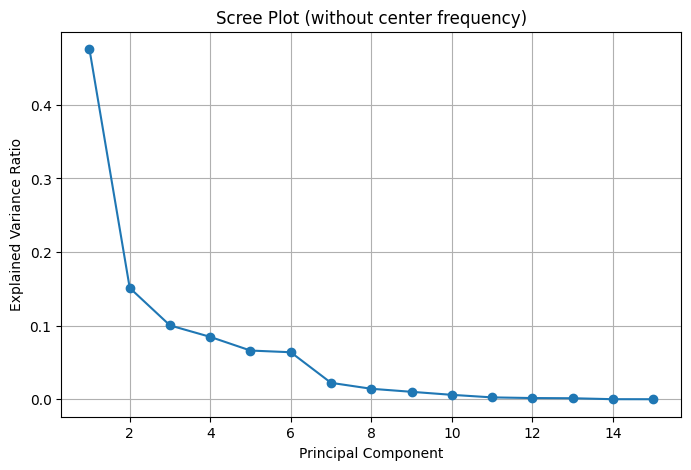

In [110]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (without center frequency)")
plt.grid(True)
plt.show()

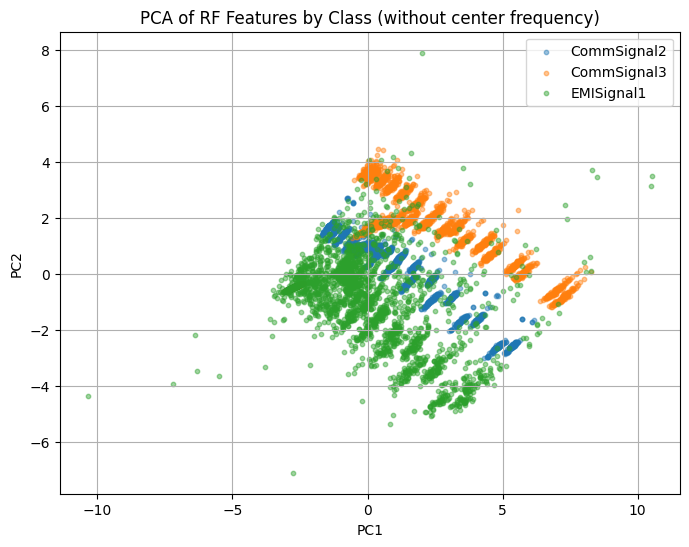

In [111]:
pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "base_class": y.values
})

plt.figure(figsize=(8,6))
for cls in pca_df["base_class"].unique():
    idx = pca_df["base_class"] == cls
    plt.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        alpha=0.45,
        s=10,
        label=cls
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of RF Features by Class (without center frequency)")
plt.legend()
plt.grid(True)
plt.show()

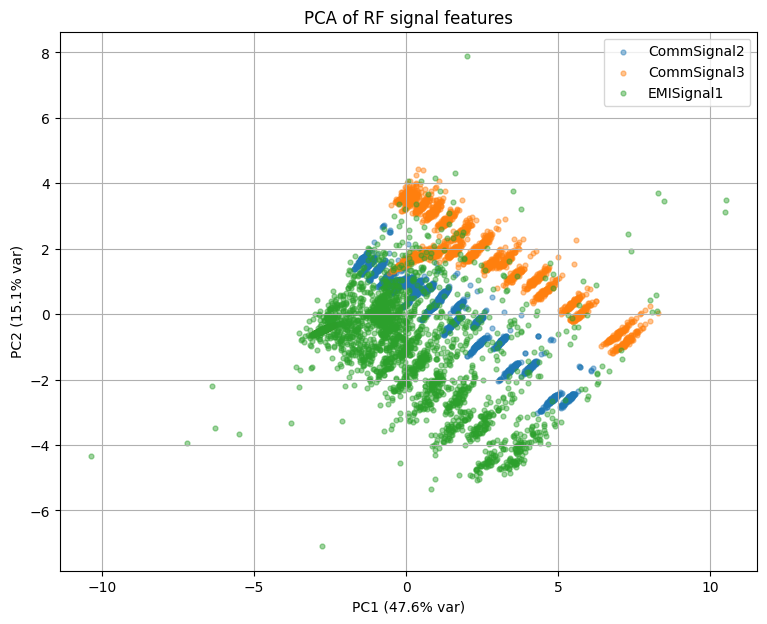

In [112]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "base_class": y.values
})

plt.figure(figsize=(9, 7))
for cls in pca_df["base_class"].unique():
    idx = pca_df["base_class"] == cls
    plt.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        s=12,
        alpha=0.45,
        label=cls
    )

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
plt.title("PCA of RF signal features")
plt.legend()
plt.grid(True)
plt.show()

The PCA projection reveals partial separation but also substantial overlap, indicating that the class structure is not fully linearly separable in the first two principal directions. At the same time, the classes exhibit distinct banded substructures, suggesting latent within-class regimes or repeated waveform configurations.

* Is PC1 mostly power/amplitude variation?
* Is PC2 mostly spectral structure?
* Is one PC mostly phase variability?
* Do CommSignal2, CommSignal3, and EMISignal1 separate along those directions?

The first principal component is primarily associated with overall signal magnitude and variability, with the strongest loadings on peak amplitude, amplitude dispersion, in-phase and quadrature standard deviations, and RMS power. The second principal component is driven more by peak-to-average ratio and spectral complexity, as reflected by strong loadings on PAPR, spectral entropy, and spectral flatness. Thus, the dominant axes of variation separate overall energy/dispersion effects from waveform-shape and spectral-structure effects.

In [113]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_no_cf,
    columns=[f"PC{i+1}" for i in range(len(feature_cols_no_cf))]
)

print("Top absolute loadings for PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False))

print("\nTop absolute loadings for PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False))

print("\nSigned loadings for PC1 and PC2:")
print(loadings[["PC1", "PC2"]].sort_values("PC1", key=np.abs, ascending=False))

ValueError: Shape of passed values is (15, 2), indices imply (15, 15)

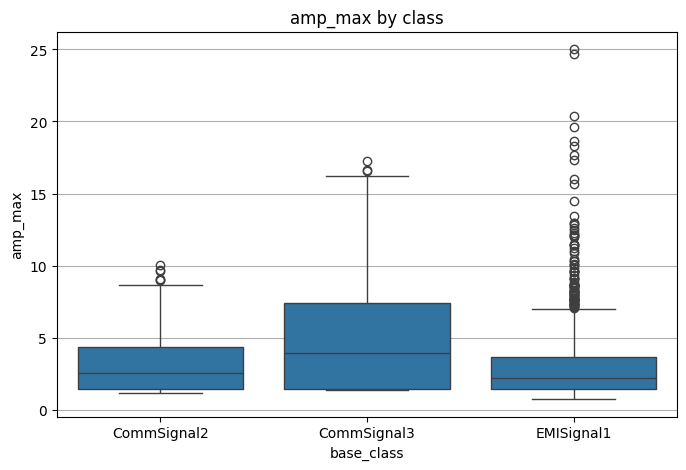

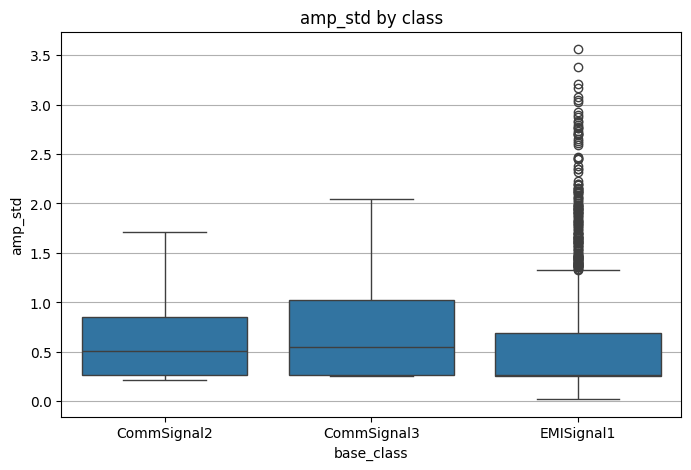

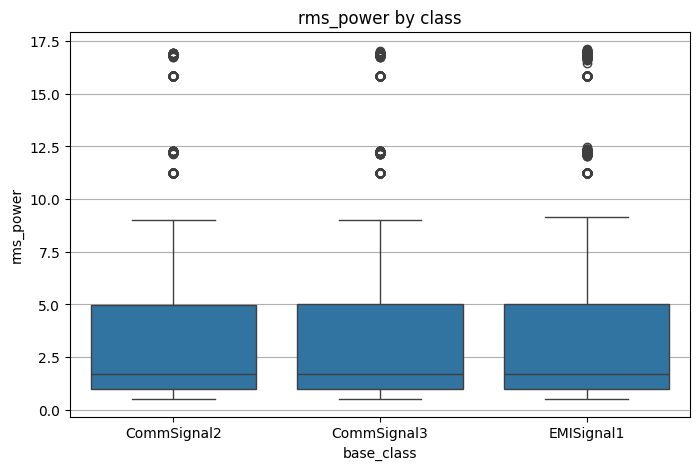

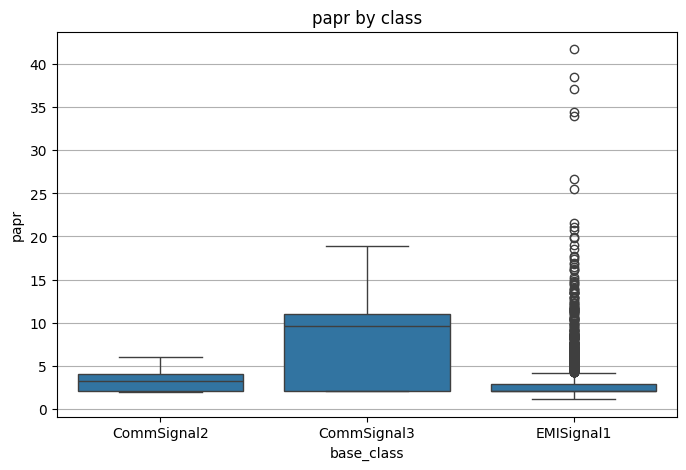

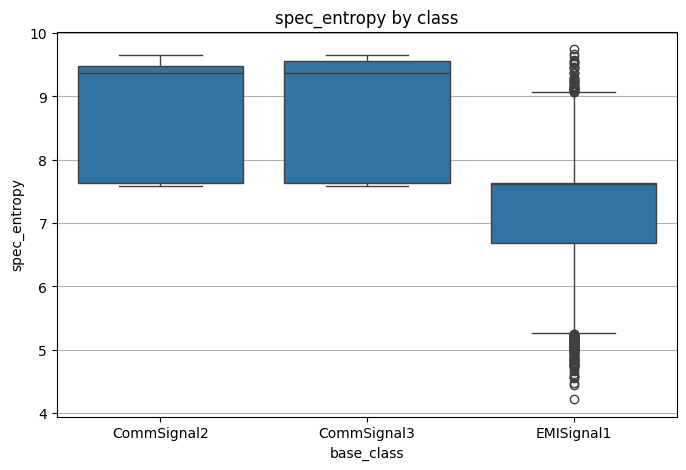

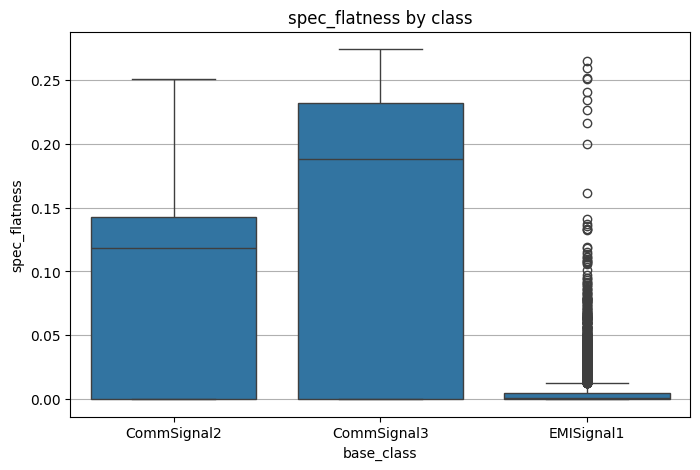

In [ ]:
for feat in ["amp_max", "amp_std", "rms_power", "papr", "spec_entropy", "spec_flatness"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="base_class", y=feat)
    plt.title(f"{feat} by class")
    plt.grid(True, axis="y")
    plt.show()

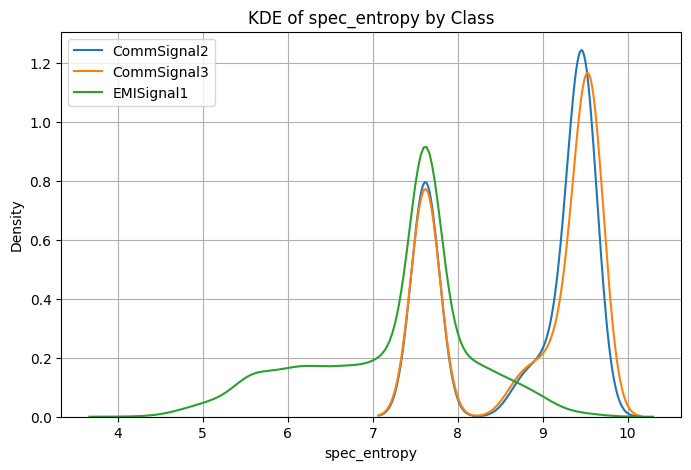

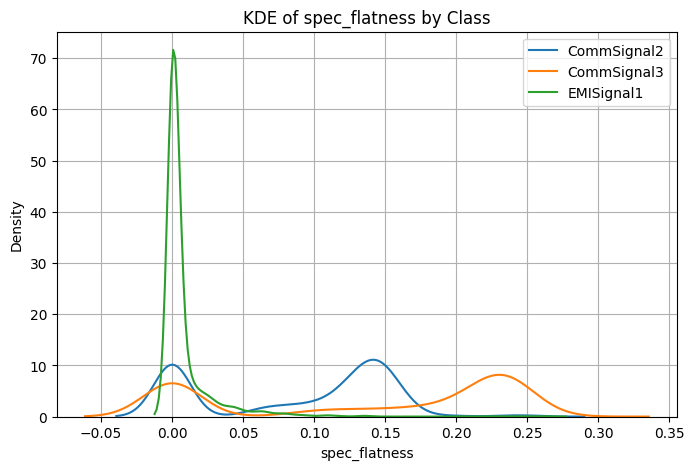

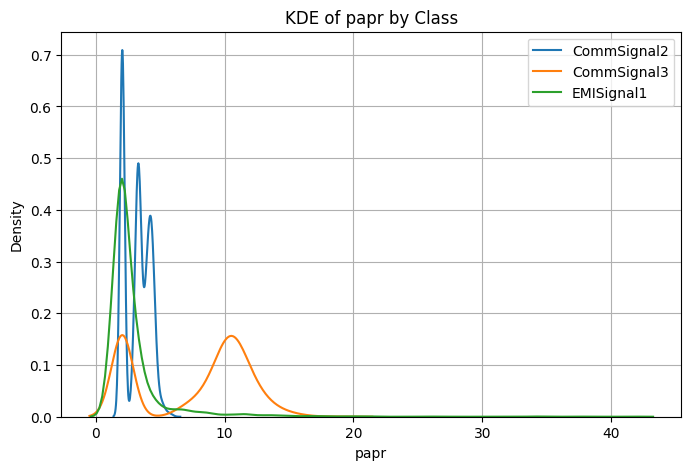

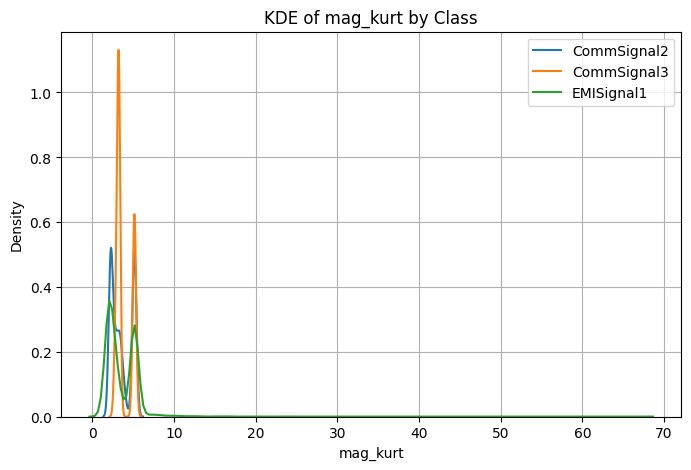

In [ ]:
for feat in ["spec_entropy", "spec_flatness", "papr", "mag_kurt"]:
    plt.figure(figsize=(8,5))
    for cls in df["base_class"].unique():
        sns.kdeplot(
            data=df[df["base_class"] == cls],
            x=feat,
            label=cls,
            fill=False
        )
    plt.title(f"KDE of {feat} by Class")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

lda = LinearDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lda, X_cls, y_cls, cv=cv, scoring="accuracy")

print("LDA CV accuracy (without center_freq):")
print("mean =", scores.mean())
print("std  =", scores.std())
print("scores =", scores)

LDA CV accuracy (without center_freq):
mean = 0.7696969696969697
std  = 0.009034618090908237
scores = [0.78686869 0.76212121 0.76616162 0.76313131 0.77020202]


In [ ]:
X_cls_cf = df[feature_cols_with_cf].copy().dropna()
y_cls_cf = df.loc[X_cls_cf.index, "base_class"]

scores_cf = cross_val_score(lda, X_cls_cf, y_cls_cf, cv=cv, scoring="accuracy")

print("LDA CV accuracy (with center_freq):")
print("mean =", scores_cf.mean())
print("std  =", scores_cf.std())
print("scores =", scores_cf)

LDA CV accuracy (with center_freq):
mean = 1.0
std  = 0.0
scores = [1. 1. 1. 1. 1.]


LDA

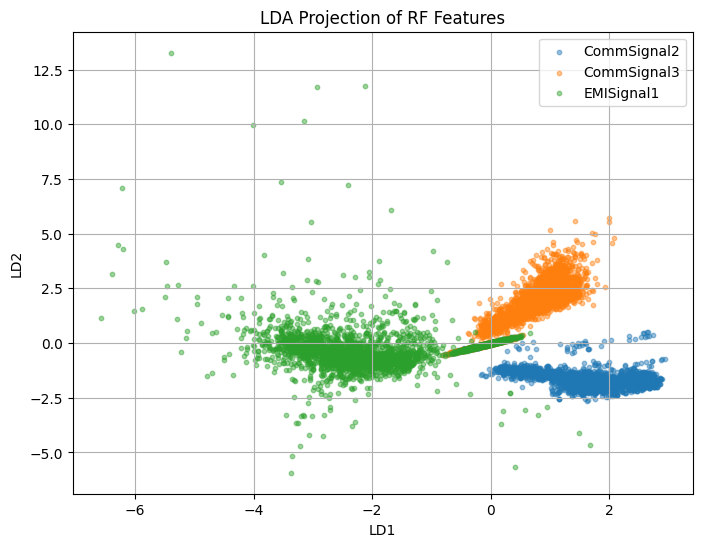

In [ ]:
lda_fit = LinearDiscriminantAnalysis(n_components=2)
Z_lda = lda_fit.fit_transform(X_cls, y_cls)

lda_df = pd.DataFrame({
    "LD1": Z_lda[:, 0],
    "LD2": Z_lda[:, 1],
    "base_class": y_cls.values
})

plt.figure(figsize=(8,6))
for cls in lda_df["base_class"].unique():
    idx = lda_df["base_class"] == cls
    plt.scatter(
        lda_df.loc[idx, "LD1"],
        lda_df.loc[idx, "LD2"],
        alpha=0.45,
        s=10,
        label=cls
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of RF Features")
plt.legend()
plt.grid(True)
plt.show()

QDA

In [ ]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

qda = QuadraticDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_qda = cross_val_score(qda, X_cls, y_cls, cv=cv, scoring="accuracy")
print("QDA CV accuracy (without center_freq):")
print("mean =", scores_qda.mean())
print("std  =", scores_qda.std())
print("scores =", scores_qda)

QDA CV accuracy (without center_freq):
mean = 0.775959595959596
std  = 0.00957520349588208
scores = [0.79393939 0.76868687 0.77020202 0.76919192 0.77777778]


d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help redu

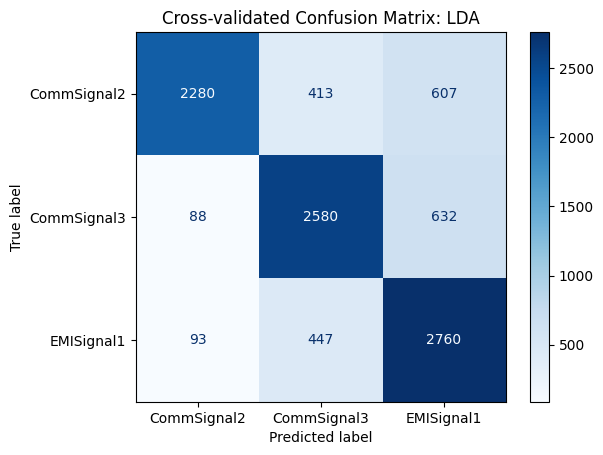

In [ ]:
y_pred = cross_val_predict(lda, X_cls, y_cls, cv=cv)

cm = confusion_matrix(y_cls, y_pred, labels=sorted(y_cls.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_cls.unique()))
disp.plot(cmap="Blues")
plt.title("Cross-validated Confusion Matrix: LDA")
plt.show()

t-SNE

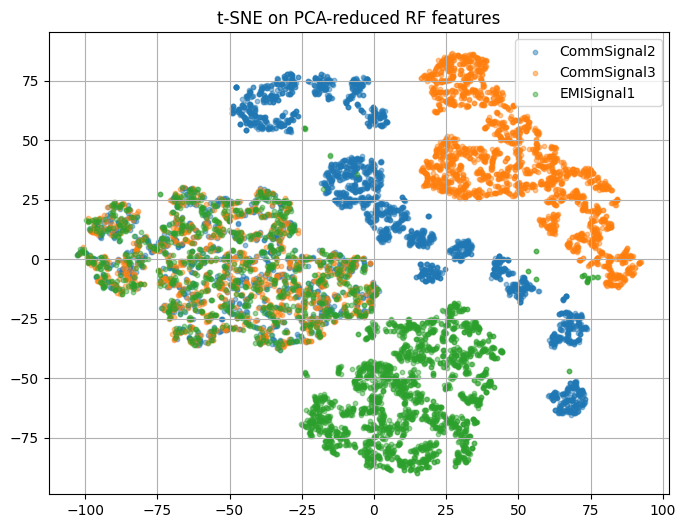

In [ ]:
X_scaled = StandardScaler().fit_transform(df[feature_cols_no_cf])
pca_8 = PCA(n_components=8)
X_pca8 = pca_8.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
T = tsne.fit_transform(X_pca8)

tsne_df = pd.DataFrame({
    "TSNE1": T[:, 0],
    "TSNE2": T[:, 1],
    "base_class": df["base_class"].values
})

plt.figure(figsize=(8,6))
for cls in tsne_df["base_class"].unique():
    idx = tsne_df["base_class"] == cls
    plt.scatter(
        tsne_df.loc[idx, "TSNE1"],
        tsne_df.loc[idx, "TSNE2"],
        alpha=0.45,
        s=10,
        label=cls
    )
plt.title("t-SNE on PCA-reduced RF features")
plt.legend()
plt.grid(True)
plt.show()

UMAP

d:\Anaconda\envs\imitation_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


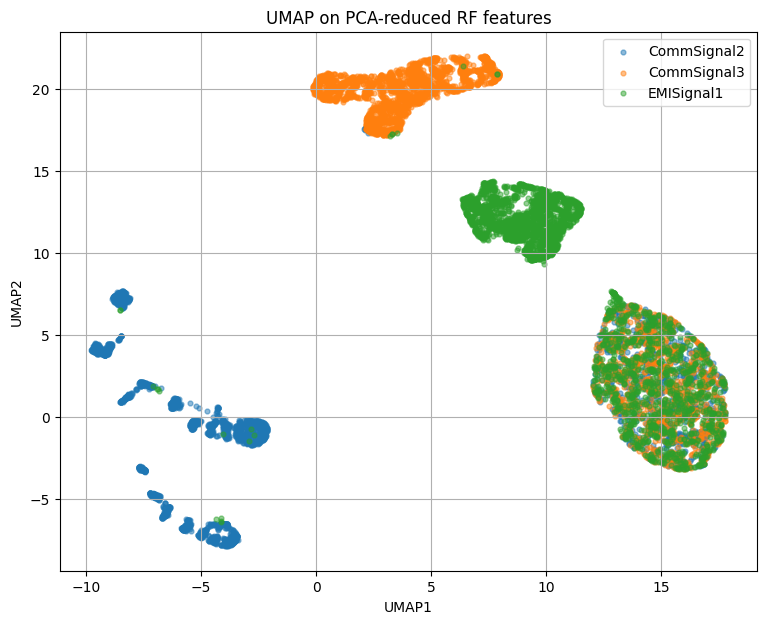

In [ ]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"].copy()

# -----------------------------
# Standardize
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Optional PCA preprocessing
# UMAP often behaves better if
# you reduce a bit first
# -----------------------------
pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# UMAP
# -----------------------------
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.15,
    metric="euclidean",
    random_state=42
)

U = reducer.fit_transform(X_pca)

umap_df = pd.DataFrame({
    "UMAP1": U[:, 0],
    "UMAP2": U[:, 1],
    "base_class": y.values
})

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 7))
for cls in umap_df["base_class"].unique():
    idx = umap_df["base_class"] == cls
    plt.scatter(
        umap_df.loc[idx, "UMAP1"],
        umap_df.loc[idx, "UMAP2"],
        s=12,
        alpha=0.5,
        label=cls
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP on PCA-reduced RF features")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

logreg = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_log = cross_val_score(logreg, X_cls, y_cls, cv=cv, scoring="accuracy")

print("Multinomial logistic CV accuracy:")
print("mean =", scores_log.mean())
print("std  =", scores_log.std())
print("scores =", scores_log)

d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWar

Multinomial logistic CV accuracy:
mean = 0.7624242424242424
std  = 0.0035511910770195635
scores = [0.76515152 0.76515152 0.76565657 0.75808081 0.75808081]


# Part B: Density and Setting Analysis

Q: Which features distinguish QPSK + CommSignal2 from QPSK + CommSignal3 or EMI mixtures? Are there density shifts that reflect mixture difficulty?

* KDE
* PCA Coordinates
* Feature Distribution Comparisons

# Part C: Predictive Modeling

## Q: Can multivariate features predict source/interference class or decoding success?
* Logistic Regression
* Ridge Regression
* Cross-Validation



In [ ]:
results_summary = pd.DataFrame({
    "Model": [
        "LDA (no center_freq)",
        "QDA (no center_freq)",
        "Multinomial Logistic (no center_freq)",
        "LDA (with center_freq)"
    ],
    "Mean CV Accuracy": [
        0.7696969696969697,
        0.775959595959596,
        0.7624242424242424,
        1.0
    ],
    "Std CV Accuracy": [
        0.009034618090908237,
        0.00957520349588208,
        0.0035511910770195635,
        0.0
    ]
})

results_summary["Mean CV Accuracy"] = results_summary["Mean CV Accuracy"].round(4)
results_summary["Std CV Accuracy"] = results_summary["Std CV Accuracy"].round(4)

print(results_summary)

                                   Model  Mean CV Accuracy  Std CV Accuracy
0                   LDA (no center_freq)            0.7697           0.0090
1                   QDA (no center_freq)            0.7760           0.0096
2  Multinomial Logistic (no center_freq)            0.7624           0.0036
3                 LDA (with center_freq)            1.0000           0.0000


In [ ]:
top_feats = ["spec_flatness", "spec_entropy", "papr", "amp_max"]

class_summary_mean = df.groupby("base_class")[top_feats].mean().round(4)
class_summary_std = df.groupby("base_class")[top_feats].std().round(4)

print("Classwise means:")
print(class_summary_mean)

print("\nClasswise standard deviations:")
print(class_summary_std)

Classwise means:
             spec_flatness  spec_entropy    papr  amp_max
base_class                                               
CommSignal2         0.0870        8.7852  3.2329   3.1917
CommSignal3         0.1374        8.8123  7.7343   5.0307
EMISignal1          0.0083        7.2680  2.8413   2.8242

Classwise standard deviations:
             spec_flatness  spec_entropy    papr  amp_max
base_class                                               
CommSignal2         0.0663        0.8431  0.9476   1.9951
CommSignal3         0.1033        0.8691  4.2552   3.7763
EMISignal1          0.0209        0.9327  2.5852   2.0336


### Results

Dataset is balanced across the three classes.

PCA:

PC1 mostly captures amplitude/power dispersion.

PC2 captures spectral complexity and peakiness.

KDE:

spec_flatness, spec_entropy, and papr separate classes strongly.

Classification:

LDA: 0.7697

QDA: 0.7760

multinomial logistic: 0.7624

with center_freq, LDA reaches 1.000

Confusion matrix:

CommSignal2 hardest to classify

EMISignal1 easiest

UMAP/t-SNE:

nonlinear structure and possible class subregimes

partial overlap remains between some CommSignal3 and EMISignal1 regions

# Part C1: Single-Channel Review And Guardrails

Before moving into the MIT recovery backend, it helps to be explicit about what the earlier single-channel-style section is doing well and where it can mislead.

Those first sections are best interpreted as **signal-family and mixture-description analysis** on the demod training set. They are useful for understanding broad class geometry, feature salience, and whether the data contains recognizable statistical structure. They are **not** the same as end-to-end separator evaluation.

One especially important caveat is that `center_freq` behaves like a near-direct dataset cue in this collection. That makes it a useful descriptive field, but not a fair stand-in for physically meaningful separation difficulty. For that reason, the no-`center_freq` models are the more honest baseline when discussing generalization.


In [ ]:
if "df" not in globals():
    print("Single-channel review skipped: base dataframe `df` is not defined yet.")
else:
    audit_feature_sets = {
        "no_center_freq": feature_cols_no_cf if "feature_cols_no_cf" in globals() else [],
        "with_center_freq": feature_cols_with_cf if "feature_cols_with_cf" in globals() else [],
    }
    audit_rows = []
    for feature_set_name, cols in audit_feature_sets.items():
        available = [col for col in cols if col in df.columns]
        if not available:
            continue
        frame = df[available]
        audit_rows.append(
            {
                "feature_set": feature_set_name,
                "n_features": len(available),
                "mean_missing_fraction": float(frame.isna().mean().mean()),
                "near_constant_features": int((frame.nunique(dropna=True) <= 2).sum()),
            }
        )

    single_channel_audit_df = pd.DataFrame(audit_rows)
    single_channel_class_balance_df = (
        df.groupby(["base_class", "kind"]).size().reset_index(name="n_rows")
        if {"base_class", "kind"}.issubset(df.columns)
        else pd.DataFrame()
    )
    single_channel_numeric_inventory_df = (
        pd.DataFrame(
            {
                "feature": df.select_dtypes(include=[np.number]).columns,
                "missing_fraction": [float(df[col].isna().mean()) for col in df.select_dtypes(include=[np.number]).columns],
                "std": [float(df[col].std()) for col in df.select_dtypes(include=[np.number]).columns],
            }
        )
        .sort_values(["missing_fraction", "std", "feature"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    print("Single-channel dataframe shape:", df.shape)
    print("Base-class counts:")
    if "base_class" in df.columns:
        print(df["base_class"].value_counts())
    print("\nFeature-set audit:")
    display(single_channel_audit_df)
    print("\nClass balance by signal family and file role:")
    display(single_channel_class_balance_df)
    print("\nMost variable numeric features:")
    display(single_channel_numeric_inventory_df.head(12))


## Single-Channel Takeaways

The early notebook results are still valuable, but they should be read with the right emphasis:

- the strongest conclusions there are about **feature geometry and class structure**,
- the cleanest baseline comparisons are the ones **excluding `center_freq`**,
- and the later MIT sections should be treated as the real recovery-side test of whether those geometric intuitions survive contact with multichannel separation and decoding.

That framing makes the notebook more coherent: the single-channel portion motivates the feature-engineering story, while the MIT sections test whether those same ideas remain useful when the task becomes actual recovery rather than descriptive classification.


# Part B: Separation / Recovery Analysis

These cells consume the MATLAB/Octave debug artifacts written by `sourceCode/evalDebugMain.m` and `evaluateSeparation_debug.m`. The CSV files give one row per frame and one row per separated output; the MAT files retain the symbol-level payload arrays for constellation inspection.

In [ ]:
from scipy.io import loadmat

challenge_root = root.parents[1] if "root" in globals() else Path.cwd()
if challenge_root.name != "mit_challenge":
    candidate = challenge_root / "mit_challenge"
    if candidate.exists():
        challenge_root = candidate

debug_root = challenge_root / "debugEval"
per_frame_files = sorted(debug_root.glob("*_perFrame.csv"))
per_output_files = sorted(debug_root.glob("*_perOutput.csv"))
debug_mat_files = sorted(debug_root.glob("*_debug.mat"))

print("Challenge root:", challenge_root)
print("Debug root:", debug_root)
print("Debug root exists:", debug_root.exists())
print("Per-frame CSV files:", len(per_frame_files))
print("Per-output CSV files:", len(per_output_files))
print("Debug MAT files:", len(debug_mat_files))

Challenge root: D:\CS 6955\CS-6955\DL-AIR\mit_challenge
Debug root: D:\CS 6955\CS-6955\DL-AIR\mit_challenge\debugEval
Debug root exists: True
Per-frame CSV files: 5
Per-output CSV files: 5
Debug MAT files: 5


In [ ]:
required_recovery_vars = ["sep_frame_df", "sep_output_df", "recovery_feature_df"]
if all(name in globals() for name in required_recovery_vars):
    print(sep_frame_df.shape)
    print(sep_output_df.shape)
    print(recovery_feature_df.shape)
    display(recovery_feature_df.head())
    print(recovery_feature_df["success"].value_counts(dropna=False))
else:
    print("Recovery tables are loaded in the recovery-side analysis section below.")

In [ ]:
def load_debug_csvs(paths):
    if not paths:
        return pd.DataFrame()

    frames = []
    for path in paths:
        part = pd.read_csv(path)
        part["source_file"] = path.name
        frames.append(part)

    return pd.concat(frames, ignore_index=True)


sep_frame_df = load_debug_csvs(per_frame_files)
sep_output_df = load_debug_csvs(per_output_files)

integer_cols = [
    "alphaIndex",
    "frameLen",
    "setIndex",
    "frame_number",
    "best_output_index",
    "output_index",
    "success",
]

for table in [sep_frame_df, sep_output_df]:
    for col in integer_cols:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")

if sep_frame_df.empty:
    print("No separation debug CSV files found yet.")
    print("Run evalDebugMain.m from mit_challenge/sourceCode after restoring mixtureData and soiParamFiles.")
else:
    print("Per-frame rows:", sep_frame_df.shape)
    print("Per-output rows:", sep_output_df.shape)
    display(sep_frame_df.head())
    display(sep_output_df.head())

Per-frame rows: (100, 8)
Per-output rows: (200, 12)


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file
0,1,4,1,1,2,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv
1,1,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv
2,1,4,1,3,2,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv
3,1,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv
4,1,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv


,alphaIndex,frameLen,setIndex,frame_number,output_index,numErrors,success,payload_mean_abs,payload_std_abs,payload_phase_std,payload_power_mean,source_file
0,1,4,1,1,1,3,0,0.886100,0.471419,1.711755,1,frameLen_4_setIndex_1_alphaIndex_1_perOutput.csv
1,1,4,1,1,2,0,1,0.966171,0.262312,1.834002,1,frameLen_4_setIndex_1_alphaIndex_1_perOutput.csv
2,1,4,1,2,1,0,1,0.993295,0.117587,1.115366,1,frameLen_4_setIndex_1_alphaIndex_1_perOutput.csv
3,1,4,1,2,2,9,0,0.910760,0.419995,1.832985,1,frameLen_4_setIndex_1_alphaIndex_1_perOutput.csv
4,1,4,1,3,1,4,0,0.912517,0.416032,2.111209,1,frameLen_4_setIndex_1_alphaIndex_1_perOutput.csv


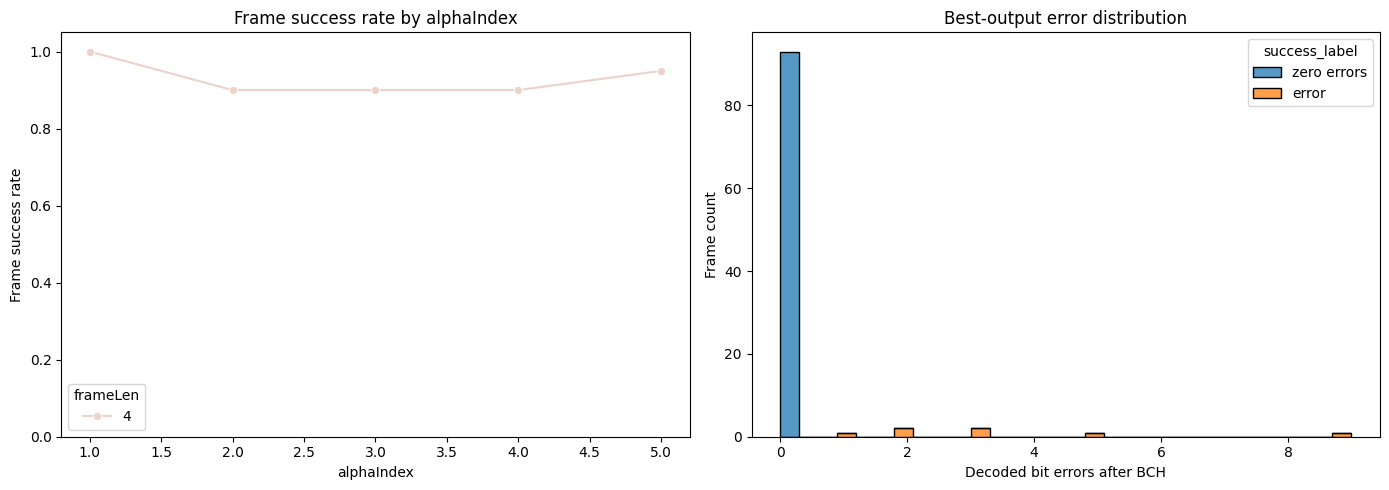

,frameLen,alphaIndex,frame_success_rate,mean_best_errors,n_frames
0,4,1,1.0,0.00,20
1,4,2,0.9,0.40,20
2,4,3,0.9,0.50,20
3,4,4,0.9,0.25,20
4,4,5,0.95,0.10,20


In [ ]:
if sep_frame_df.empty:
    print("Frame-level recovery plots will populate after debug CSVs are generated.")
else:
    frame_plot_df = sep_frame_df.copy()
    frame_plot_df["success_label"] = frame_plot_df["success"].map({0: "error", 1: "zero errors"})

    alpha_summary = (
        frame_plot_df
        .groupby(["frameLen", "alphaIndex"], as_index=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if alpha_summary["alphaIndex"].nunique() > 1:
        sns.lineplot(
            data=alpha_summary,
            x="alphaIndex",
            y="frame_success_rate",
            hue="frameLen",
            marker="o",
            ax=axes[0],
        )
    else:
        sns.barplot(
            data=alpha_summary,
            x="alphaIndex",
            y="frame_success_rate",
            hue="frameLen",
            ax=axes[0],
        )

    axes[0].set_title("Frame success rate by alphaIndex")
    axes[0].set_xlabel("alphaIndex")
    axes[0].set_ylabel("Frame success rate")
    axes[0].set_ylim(0, 1.05)

    sns.histplot(
        data=frame_plot_df,
        x="best_num_errors",
        hue="success_label",
        multiple="stack",
        bins=30,
        ax=axes[1],
    )
    axes[1].set_title("Best-output error distribution")
    axes[1].set_xlabel("Decoded bit errors after BCH")
    axes[1].set_ylabel("Frame count")

    plt.tight_layout()
    plt.show()

    display(alpha_summary.head(10))

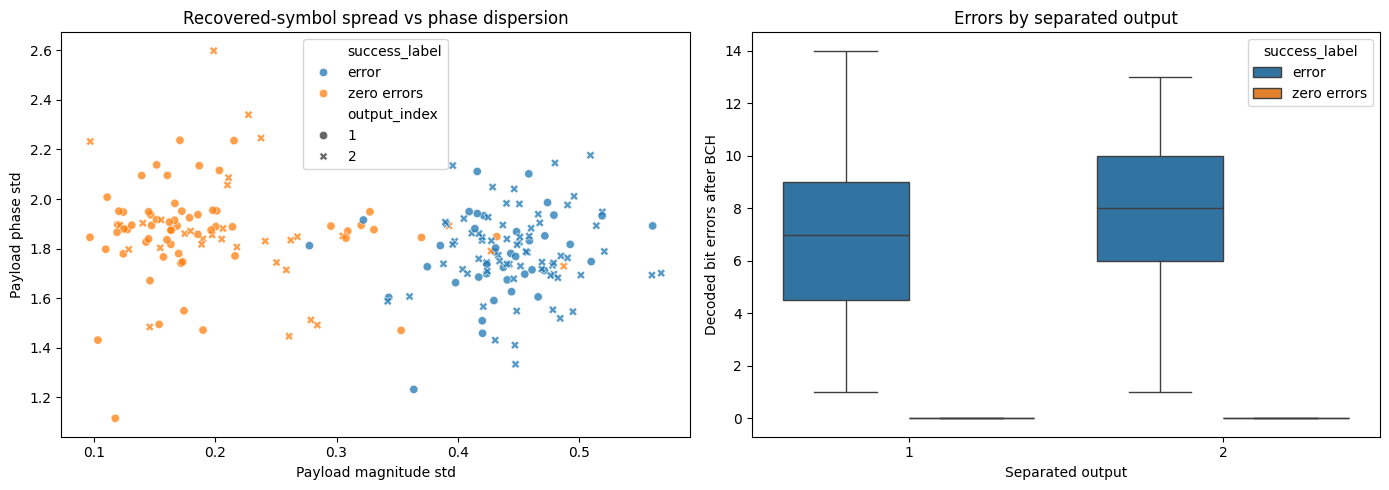

In [ ]:
if sep_output_df.empty:
    print("Per-output constellation summary plots will populate after debug CSVs are generated.")
else:
    output_plot_df = sep_output_df.copy()
    output_plot_df["success_label"] = output_plot_df["success"].map({0: "error", 1: "zero errors"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(
        data=output_plot_df,
        x="payload_std_abs",
        y="payload_phase_std",
        hue="success_label",
        style="output_index",
        alpha=0.75,
        ax=axes[0],
    )
    axes[0].set_title("Recovered-symbol spread vs phase dispersion")
    axes[0].set_xlabel("Payload magnitude std")
    axes[0].set_ylabel("Payload phase std")

    sns.boxplot(
        data=output_plot_df,
        x="output_index",
        y="numErrors",
        hue="success_label",
        ax=axes[1],
    )
    axes[1].set_title("Errors by separated output")
    axes[1].set_xlabel("Separated output")
    axes[1].set_ylabel("Decoded bit errors after BCH")

    plt.tight_layout()
    plt.show()

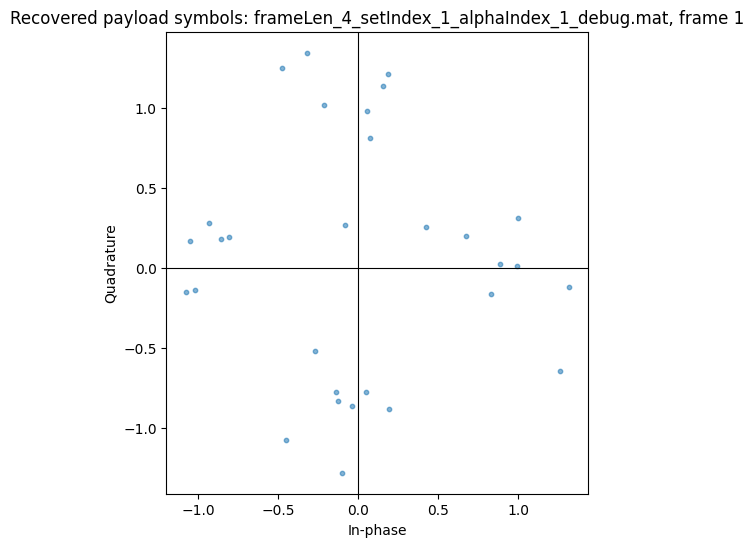

In [ ]:
def debug_field(debug_obj, name):
    if isinstance(debug_obj, dict):
        return debug_obj[name]
    return getattr(debug_obj, name)


if not debug_mat_files:
    print("No symbol-level debug MAT files found yet.")
else:
    try:
        sample_mat = loadmat(debug_mat_files[0], squeeze_me=True, simplify_cells=True)
        debug_out = sample_mat["debugOut"]
        payload_cells = debug_field(debug_out, "rxSymsPayload")
        best_output = int(np.asarray(debug_field(debug_out, "bestOutputIndex")).ravel()[0]) - 1

        payload = np.asarray(payload_cells[0][best_output]).ravel()

        plt.figure(figsize=(6, 6))
        plt.scatter(payload.real, payload.imag, s=10, alpha=0.55)
        plt.axhline(0, color="black", linewidth=0.8)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.title(f"Recovered payload symbols: {debug_mat_files[0].name}, frame 1")
        plt.xlabel("In-phase")
        plt.ylabel("Quadrature")
        plt.show()
    except Exception as exc:
        print("Could not load symbol-level MAT debug file:", exc)

In [ ]:
feature_candidate_paths = [
    challenge_root / "separation_frame_features.csv",
    challenge_root / "frame_feature_summary.csv",
]
feature_path = next((path for path in feature_candidate_paths if path.exists()), None)

recovery_feature_df = pd.DataFrame()
model_feature_cols = []

if sep_frame_df.empty:
    print("Recovery-feature modeling will populate after per-frame debug CSVs are generated.")
elif feature_path is not None:
    frame_feature_df = pd.read_csv(feature_path)
    merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
    recovery_feature_df = sep_frame_df.merge(frame_feature_df, on=merge_keys, how="inner")

    blocked_cols = set(merge_keys + ["success", "best_num_errors", "best_output_index"])
    model_feature_cols = [
        col for col in recovery_feature_df.select_dtypes(include=[np.number]).columns
        if col not in blocked_cols
    ]
    print("Merged MATLAB recovery labels with Python frame features:", recovery_feature_df.shape)
elif not sep_output_df.empty:
    merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
    best_output_rows = (
        sep_output_df
        .sort_values("numErrors")
        .groupby(merge_keys, as_index=False)
        .head(1)
    )
    constellation_cols = ["payload_mean_abs", "payload_std_abs", "payload_phase_std", "payload_power_mean"]
    recovery_feature_df = sep_frame_df.merge(best_output_rows[merge_keys + constellation_cols], on=merge_keys, how="left")
    model_feature_cols = constellation_cols
    print("Using debug-derived constellation summary features until an external frame-feature CSV is available.")

if not recovery_feature_df.empty:
    print("Candidate model features:", model_feature_cols)
    display(recovery_feature_df.head())

Merged MATLAB recovery labels with Python frame features: (100, 55)
Candidate model features: ['n_samples_per_channel', 'ch1_power', 'ch1_amp_mean', 'ch1_amp_std', 'ch1_amp_max', 'ch1_papr', 'ch2_power', 'ch2_amp_mean', 'ch2_amp_std', 'ch2_amp_max', 'ch2_papr', 'ch3_power', 'ch3_amp_mean', 'ch3_amp_std', 'ch3_amp_max', 'ch3_papr', 'ch4_power', 'ch4_amp_mean', 'ch4_amp_std', 'ch4_amp_max', 'ch4_papr', 'power_mean', 'power_std', 'power_max', 'amp_mean_all', 'amp_std_all', 'amp_max_all', 'cov_eig_1', 'cov_eig_2', 'cov_eig_3', 'cov_eig_4', 'cov_trace', 'cov_condition', 'offdiag_cov_abs_mean', 'offdiag_cov_abs_std', 'offdiag_cov_abs_max', 'coherence_mean', 'coherence_std', 'coherence_max', 'spec_entropy_mean', 'spec_entropy_std', 'spec_flatness_mean', 'spec_flatness_std', 'spec_centroid_mean', 'spec_centroid_std', 'spec_bandwidth_mean', 'spec_bandwidth_std']


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file,n_samples_per_channel,ch1_power,...,coherence_std,coherence_max,spec_entropy_mean,spec_entropy_std,spec_flatness_mean,spec_flatness_std,spec_centroid_mean,spec_centroid_std,spec_bandwidth_mean,spec_bandwidth_std
0,1,4,1,1,2,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv,111,1.046555,...,0.271374,0.679540,4.204234,0.028086,0.524343,0.021419,-0.016681,0.002814,0.306885,0.002468
1,1,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv,111,1.093750,...,0.256381,0.570317,4.050103,0.062470,0.438377,0.002470,-0.014293,0.005757,0.270726,0.004600
2,1,4,1,3,2,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv,111,1.038904,...,0.220736,0.584325,4.121443,0.056586,0.497067,0.021774,-0.006052,0.015020,0.267847,0.005718
3,1,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv,111,1.082906,...,0.226671,0.579071,4.207934,0.047941,0.497992,0.024743,0.010920,0.006669,0.297646,0.003430
4,1,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_1_perFrame.csv,111,1.088346,...,0.256795,0.654654,4.239274,0.048807,0.534855,0.040602,-0.017817,0.008569,0.309803,0.002391


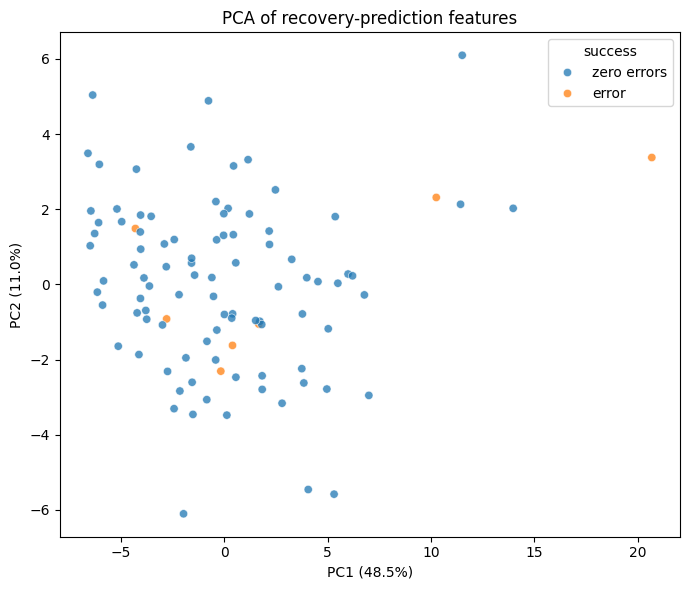

d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help redu

,Model,Mean CV Accuracy,Std CV Accuracy
0,LDA,0.76,0.1158
1,QDA,0.94,0.0374
2,Logistic,0.90,0.0316


In [ ]:
if recovery_feature_df.empty or not model_feature_cols:
    print("No recovery feature table is available for PCA/classification yet.")
else:
    X_rec = recovery_feature_df[model_feature_cols].replace([np.inf, -np.inf], np.nan)
    X_rec = X_rec.dropna(axis=0)
    y_rec = recovery_feature_df.loc[X_rec.index, "success"].astype(int)

    if y_rec.nunique() < 2:
        print("Need both successful and failed frames before fitting recovery classifiers.")
    elif len(X_rec) < 10:
        print("Need at least 10 complete debug rows before fitting recovery classifiers.")
    else:
        X_rec_scaled = StandardScaler().fit_transform(X_rec)
        n_components = min(2, X_rec.shape[1])
        pca_rec = PCA(n_components=n_components)
        Z_rec = pca_rec.fit_transform(X_rec_scaled)

        pca_rec_df = pd.DataFrame({
            "PC1": Z_rec[:, 0],
            "PC2": Z_rec[:, 1] if n_components > 1 else 0.0,
            "success": y_rec.map({0: "error", 1: "zero errors"}).values,
        })

        plt.figure(figsize=(7, 6))
        sns.scatterplot(data=pca_rec_df, x="PC1", y="PC2", hue="success", alpha=0.75)
        plt.title("PCA of recovery-prediction features")
        plt.xlabel(f"PC1 ({pca_rec.explained_variance_ratio_[0]:.1%})")
        plt.ylabel(f"PC2 ({pca_rec.explained_variance_ratio_[1]:.1%})" if n_components > 1 else "PC2")
        plt.tight_layout()
        plt.show()

        min_class_count = y_rec.value_counts().min()
        if min_class_count < 2:
            print("Cross-validation skipped because one class has fewer than two frames.")
        else:
            n_splits = min(5, int(min_class_count))
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            recovery_models = {
                "LDA": LinearDiscriminantAnalysis(),
                "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
                "Logistic": LogisticRegression(max_iter=2000),
            }

            recovery_scores = []
            for name, model in recovery_models.items():
                scores = cross_val_score(model, X_rec_scaled, y_rec, cv=cv, scoring="accuracy")
                recovery_scores.append({
                    "Model": name,
                    "Mean CV Accuracy": scores.mean(),
                    "Std CV Accuracy": scores.std(),
                })

            display(pd.DataFrame(recovery_scores).round(4))

# Part C: Recovery-Side Analysis

This section joins the Octave debug recovery outputs with frame-level mixture features from `separation_frame_features.csv`. It focuses on which multivariate mixture statistics are associated with successful symbol recovery after separation.

In [ ]:
from pathlib import Path
import warnings

from scipy.io import loadmat
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

challenge_root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge")
debug_root = challenge_root / "debugEval"
frame_feature_path = challenge_root / "separation_frame_features.csv"
merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]

def load_debug_csvs(paths):
    if not paths:
        return pd.DataFrame()
    tables = []
    for path in paths:
        table = pd.read_csv(path)
        table["source_file"] = path.name
        tables.append(table)
    return pd.concat(tables, ignore_index=True)

def normalize_key_columns(table):
    for col in merge_keys + ["success", "best_output_index", "output_index"]:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")
    return table

per_frame_files = sorted(debug_root.glob("*_perFrame.csv"))
per_output_files = sorted(debug_root.glob("*_perOutput.csv"))
debug_mat_files = sorted(debug_root.glob("*_debug.mat"))

sep_frame_df = normalize_key_columns(load_debug_csvs(per_frame_files))
sep_output_df = normalize_key_columns(load_debug_csvs(per_output_files))
frame_feature_df = pd.read_csv(frame_feature_path) if frame_feature_path.exists() else pd.DataFrame()
frame_feature_df = normalize_key_columns(frame_feature_df) if not frame_feature_df.empty else frame_feature_df

if sep_frame_df.empty:
    print("No per-frame recovery CSVs found in", debug_root)
if sep_output_df.empty:
    print("No per-output recovery CSVs found in", debug_root)
if frame_feature_df.empty:
    print("No frame feature CSV found at", frame_feature_path)

if not sep_frame_df.empty and not frame_feature_df.empty:
    recovery_feature_df = sep_frame_df.merge(frame_feature_df, on=merge_keys, how="inner")
else:
    recovery_feature_df = pd.DataFrame()

print("per-frame files:", len(per_frame_files))
print("per-output files:", len(per_output_files))
print("debug MAT files:", len(debug_mat_files))
print("sep_frame_df shape:", sep_frame_df.shape)
print("sep_output_df shape:", sep_output_df.shape)
print("frame_feature_df shape:", frame_feature_df.shape)
print("recovery_feature_df shape:", recovery_feature_df.shape)

if not sep_frame_df.empty:
    print("sep_frame_df columns:")
    print(list(sep_frame_df.columns))
    display(sep_frame_df.head())

if not sep_output_df.empty:
    print("sep_output_df columns:")
    print(list(sep_output_df.columns))
    display(sep_output_df.head())

if not recovery_feature_df.empty:
    print("recovery_feature_df columns:")
    print(list(recovery_feature_df.columns))
    display(recovery_feature_df.head())
    print("success counts:")
    print(recovery_feature_df["success"].value_counts(dropna=False).sort_index())

per-frame files: 15
per-output files: 15
debug MAT files: 15
sep_frame_df shape: (1500, 8)
sep_output_df shape: (3000, 12)
frame_feature_df shape: (1500, 51)
recovery_feature_df shape: (1500, 55)
sep_frame_df columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'best_output_index', 'best_num_errors', 'success', 'source_file']


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file
0,10,4,1,1,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
1,10,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
2,10,4,1,3,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
3,10,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
4,10,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv


sep_output_df columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'output_index', 'numErrors', 'success', 'payload_mean_abs', 'payload_std_abs', 'payload_phase_std', 'payload_power_mean', 'source_file']


,alphaIndex,frameLen,setIndex,frame_number,output_index,numErrors,success,payload_mean_abs,payload_std_abs,payload_phase_std,payload_power_mean,source_file
0,10,4,1,1,1,0,1,0.973549,0.232385,1.529508,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
1,10,4,1,1,2,7,0,0.873792,0.494613,1.956597,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
2,10,4,1,2,1,0,1,0.984177,0.180218,2.153285,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
3,10,4,1,2,2,4,0,0.925038,0.386369,2.179054,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
4,10,4,1,3,1,0,1,0.987049,0.163165,1.851892,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv


recovery_feature_df columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'best_output_index', 'best_num_errors', 'success', 'source_file', 'n_samples_per_channel', 'ch1_power', 'ch1_amp_mean', 'ch1_amp_std', 'ch1_amp_max', 'ch1_papr', 'ch2_power', 'ch2_amp_mean', 'ch2_amp_std', 'ch2_amp_max', 'ch2_papr', 'ch3_power', 'ch3_amp_mean', 'ch3_amp_std', 'ch3_amp_max', 'ch3_papr', 'ch4_power', 'ch4_amp_mean', 'ch4_amp_std', 'ch4_amp_max', 'ch4_papr', 'power_mean', 'power_std', 'power_max', 'amp_mean_all', 'amp_std_all', 'amp_max_all', 'cov_eig_1', 'cov_eig_2', 'cov_eig_3', 'cov_eig_4', 'cov_trace', 'cov_condition', 'offdiag_cov_abs_mean', 'offdiag_cov_abs_std', 'offdiag_cov_abs_max', 'coherence_mean', 'coherence_std', 'coherence_max', 'spec_entropy_mean', 'spec_entropy_std', 'spec_flatness_mean', 'spec_flatness_std', 'spec_centroid_mean', 'spec_centroid_std', 'spec_bandwidth_mean', 'spec_bandwidth_std']


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file,n_samples_per_channel,ch1_power,...,coherence_std,coherence_max,spec_entropy_mean,spec_entropy_std,spec_flatness_mean,spec_flatness_std,spec_centroid_mean,spec_centroid_std,spec_bandwidth_mean,spec_bandwidth_std
0,10,4,1,1,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.165391,...,0.142703,0.399508,4.251977,0.057244,0.546171,0.047234,-0.055337,0.035518,0.271606,0.009331
1,10,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.324642,...,0.168710,0.454830,4.220219,0.084112,0.510523,0.048820,-0.014543,0.030964,0.281135,0.008781
2,10,4,1,3,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,3.629893,...,0.158961,0.428296,4.280434,0.024807,0.580396,0.025518,-0.041344,0.010818,0.278740,0.017215
3,10,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.152381,...,0.122101,0.343138,4.227621,0.044936,0.533771,0.044401,-0.013924,0.016695,0.281625,0.004149
4,10,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,1.961137,...,0.094016,0.376667,4.246631,0.013631,0.550149,0.019775,0.004846,0.011220,0.286573,0.013596


success counts:
success
0     280
1    1220
Name: count, dtype: Int64


,alphaIndex,frame_success_rate,mean_best_errors,n_frames
0,1,0.91,0.26,100
1,2,0.84,0.72,100
2,3,0.91,0.41,100
3,4,0.89,0.61,100
4,5,0.84,0.77,100
5,6,0.91,0.37,100
6,7,0.81,0.78,100
7,8,0.91,0.31,100
8,9,0.85,0.53,100
9,10,0.84,0.59,100


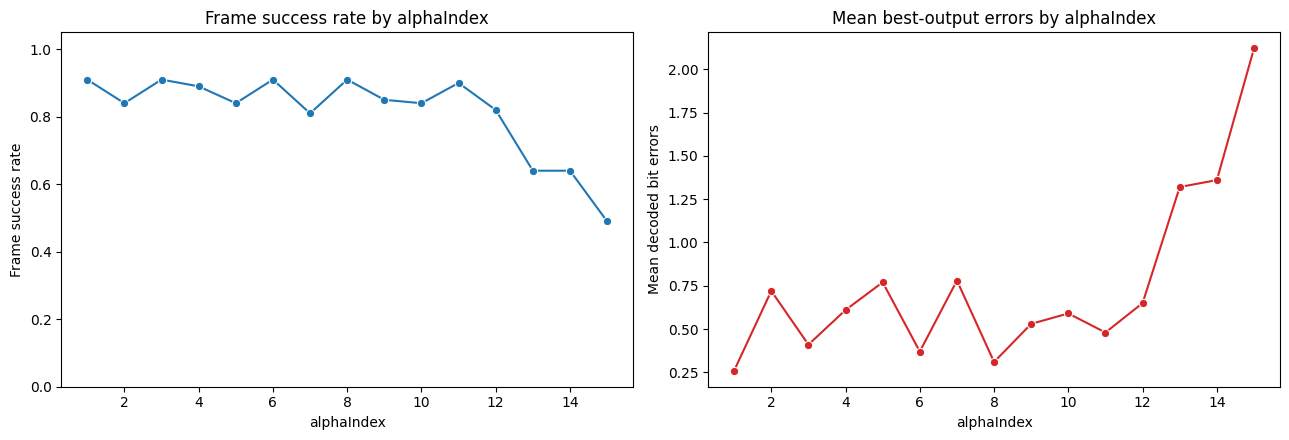

In [ ]:
alpha_summary = pd.DataFrame()

if recovery_feature_df.empty:
    print("Skipping alpha-level recovery summaries because recovery_feature_df is empty.")
else:
    alpha_summary = (
        recovery_feature_df
        .groupby("alphaIndex", as_index=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
        )
    )
    display(alpha_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.lineplot(data=alpha_summary, x="alphaIndex", y="frame_success_rate", marker="o", ax=axes[0])
    axes[0].set_title("Frame success rate by alphaIndex")
    axes[0].set_xlabel("alphaIndex")
    axes[0].set_ylabel("Frame success rate")
    axes[0].set_ylim(0, 1.05)

    sns.lineplot(data=alpha_summary, x="alphaIndex", y="mean_best_errors", marker="o", color="tab:red", ax=axes[1])
    axes[1].set_title("Mean best-output errors by alphaIndex")
    axes[1].set_xlabel("alphaIndex")
    axes[1].set_ylabel("Mean decoded bit errors")

    plt.tight_layout()
    plt.show()

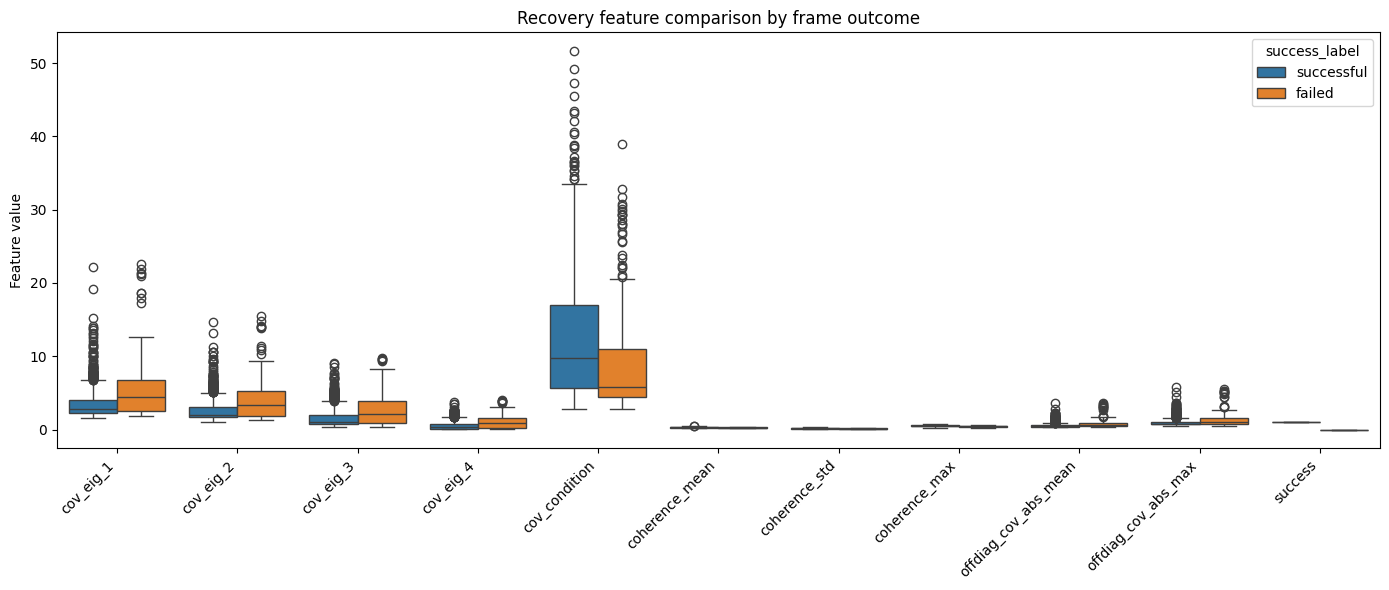

cov_eig_1         cov_eig_2         cov_eig_3         cov_eig_4  \
             mean     std      mean     std      mean     std      mean   
success                                                                   
0          5.1620  3.6280    3.8766  2.5427    2.5804  1.9641    0.9960   
1          3.5604  2.0408    2.6414  1.5500    1.5561  1.2907    0.5352   

                cov_condition         coherence_mean         coherence_std  \
            std          mean     std           mean     std          mean   
success                                                                      
0        0.8759        9.1547  7.2043         0.2693  0.0519        0.1521   
1        0.5773       12.3469  8.3096         0.2958  0.0536        0.1814   

                coherence_max         offdiag_cov_abs_mean          \
            std          mean     std                 mean     std   
success                                                              
0        0.0574        0.4510  0.1010               0.7871  0.5432   
1        0.0545        0.5048  0.0969               0.5650  0.2854   

        offdiag_cov_abs_max          
                       mean     std  
success                              
0                    1.3186  0.8562  
1                    0.9756  0.4721

In [ ]:
candidate_recovery_features = [
    "cov_eig_1", "cov_eig_2", "cov_eig_3", "cov_eig_4", "cov_condition",
    "coherence_mean", "coherence_std", "coherence_max",
    "offdiag_cov_abs_mean", "offdiag_cov_abs_max",
    "spec_entropy_mean", "spec_flatness_mean", "spec_bandwidth_mean",
    "power_mean", "power_std", "power_max",
    "ch1_power", "ch2_power", "ch3_power", "ch4_power",
    "ch1_papr", "ch2_papr", "ch3_papr", "ch4_papr",
    "amp_std_all", "amp_max_all",
]

available_recovery_features = [col for col in candidate_recovery_features if col in recovery_feature_df.columns]

if recovery_feature_df.empty or not available_recovery_features:
    print("Skipping feature comparison because recovery features are unavailable.")
elif recovery_feature_df["success"].nunique() < 2:
    print("Only one success class is present; showing feature/error correlations instead of success/failure boxplots.")
    corr_table = (
        recovery_feature_df[available_recovery_features + ["best_num_errors"]]
        .corr(numeric_only=True)["best_num_errors"]
        .drop("best_num_errors")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .head(12)
    )
    display(corr_table.to_frame("corr_with_best_num_errors"))
else:
    plot_features = available_recovery_features[:10]
    feature_long = recovery_feature_df[plot_features + ["success"]].copy()
    feature_long["success_label"] = feature_long["success"].map({0: "failed", 1: "successful"})
    feature_long = feature_long.melt(id_vars="success_label", var_name="feature", value_name="value")

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=feature_long, x="feature", y="value", hue="success_label")
    plt.xticks(rotation=45, ha="right")
    plt.title("Recovery feature comparison by frame outcome")
    plt.xlabel("")
    plt.ylabel("Feature value")
    plt.tight_layout()
    plt.show()

    summary = recovery_feature_df.groupby("success")[plot_features].agg(["mean", "std"]).round(4)
    display(summary)

Recovery PCA explained variance ratio: [0.69328889 0.07696107]


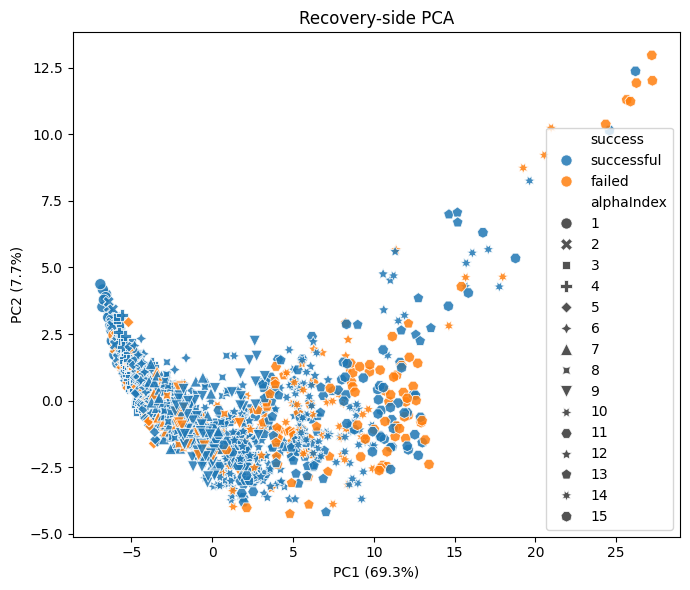

Top absolute loadings for PC1:


,PC1
amp_std_all,0.176212
amp_mean_all,0.175208
ch2_amp_mean,0.174090
ch2_amp_std,0.174090
ch1_amp_std,0.173891
ch3_amp_std,0.173827
ch4_amp_mean,0.173787
ch3_amp_mean,0.173750
ch1_amp_mean,0.173735
ch4_amp_std,0.173643


Top absolute loadings for PC2:


,PC2
offdiag_cov_abs_std,0.271730
cov_condition,0.266847
spec_centroid_std,-0.256943
coherence_mean,0.250245
ch1_papr,-0.247322
ch3_papr,-0.246011
coherence_max,0.246003
ch4_papr,-0.234817
coherence_std,0.229675
offdiag_cov_abs_max,0.214259


In [ ]:
feature_cols_rec = []
pca_loadings_rec = pd.DataFrame()

if recovery_feature_df.empty:
    print("Skipping recovery PCA because recovery_feature_df is empty.")
else:
    excluded_cols = set(merge_keys + ["success", "best_num_errors", "best_output_index"])
    feature_cols_rec = [
        col for col in recovery_feature_df.select_dtypes(include=[np.number]).columns
        if col not in excluded_cols
    ]
    X_rec = recovery_feature_df[feature_cols_rec].replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    y_rec = recovery_feature_df.loc[X_rec.index, "success"].astype(int)

    if X_rec.shape[0] < 2 or X_rec.shape[1] < 2:
        print("Need at least two rows and two numeric features for recovery PCA.")
    else:
        X_rec_scaled = StandardScaler().fit_transform(X_rec)
        pca_rec = PCA(n_components=2, random_state=42)
        Z_rec = pca_rec.fit_transform(X_rec_scaled)
        pca_rec_df = pd.DataFrame({
            "PC1": Z_rec[:, 0],
            "PC2": Z_rec[:, 1],
            "success": y_rec.map({0: "failed", 1: "successful"}).values,
            "alphaIndex": recovery_feature_df.loc[X_rec.index, "alphaIndex"].astype(int).values,
        })

        print("Recovery PCA explained variance ratio:", pca_rec.explained_variance_ratio_)

        plt.figure(figsize=(7, 6))
        sns.scatterplot(data=pca_rec_df, x="PC1", y="PC2", hue="success", style="alphaIndex", s=65, alpha=0.85)
        plt.title("Recovery-side PCA")
        plt.xlabel(f"PC1 ({pca_rec.explained_variance_ratio_[0]:.1%})")
        plt.ylabel(f"PC2 ({pca_rec.explained_variance_ratio_[1]:.1%})")
        plt.tight_layout()
        plt.show()

        pca_loadings_rec = pd.DataFrame(
            pca_rec.components_.T,
            index=feature_cols_rec,
            columns=["PC1", "PC2"],
        )
        top_pc1 = pca_loadings_rec["PC1"].abs().sort_values(ascending=False).head(10).index
        top_pc2 = pca_loadings_rec["PC2"].abs().sort_values(ascending=False).head(10).index

        print("Top absolute loadings for PC1:")
        display(pca_loadings_rec.loc[top_pc1, ["PC1"]].sort_values("PC1", key=lambda s: s.abs(), ascending=False))
        print("Top absolute loadings for PC2:")
        display(pca_loadings_rec.loc[top_pc2, ["PC2"]].sort_values("PC2", key=lambda s: s.abs(), ascending=False))

Eight strongest recovery-side PCA-loading features:


,max_abs_loading_PC1_PC2
offdiag_cov_abs_std,0.271730
cov_condition,0.266847
spec_centroid_std,0.256943
coherence_mean,0.250245
ch1_papr,0.247322
ch3_papr,0.246011
coherence_max,0.246003
ch4_papr,0.234817


Features plotted: ['offdiag_cov_abs_std', 'cov_condition', 'spec_centroid_std', 'coherence_mean']


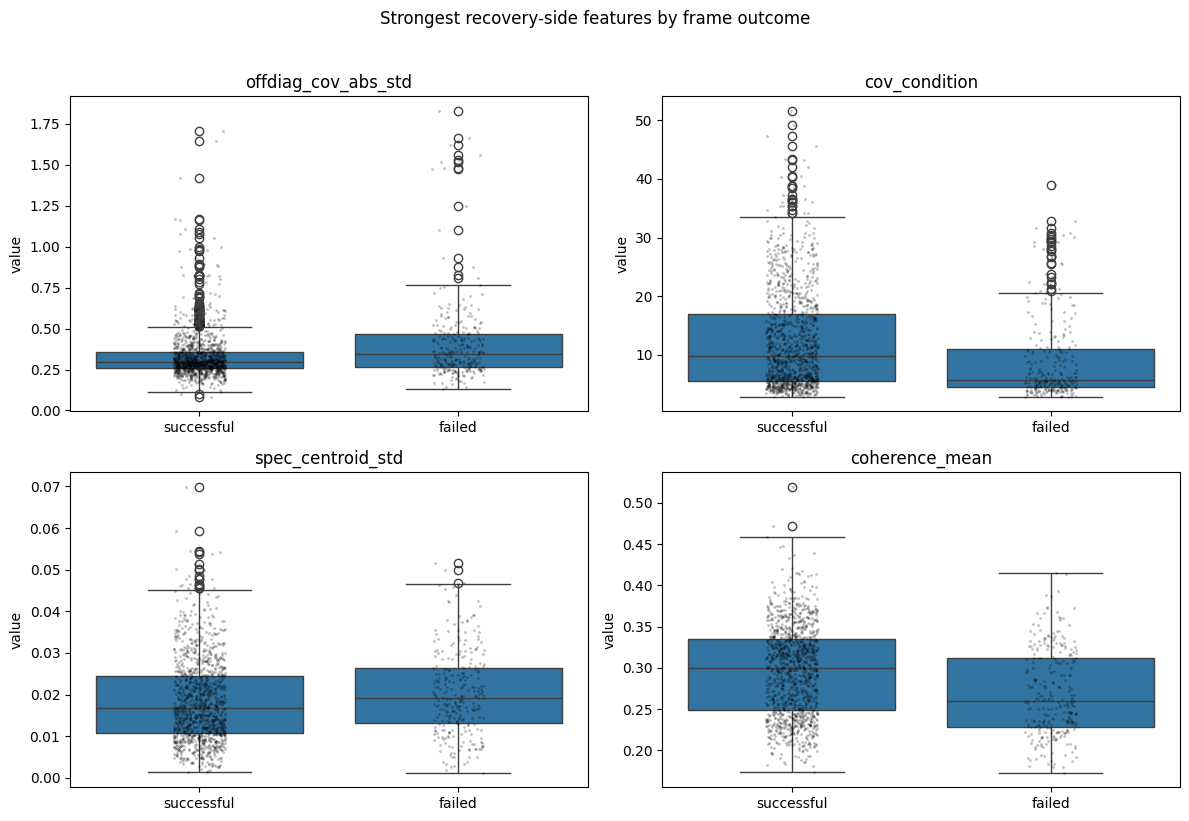

In [ ]:
strongest_recovery_features = []
plotted_recovery_features = []

if recovery_feature_df.empty or pca_loadings_rec.empty:
    print("Skipping strongest-feature plots because PCA loadings are unavailable.")
else:
    loading_strength = pca_loadings_rec.abs().max(axis=1).sort_values(ascending=False)
    strongest_recovery_features = loading_strength.head(8).index.tolist()
    plotted_recovery_features = strongest_recovery_features[:4]

    print("Eight strongest recovery-side PCA-loading features:")
    display(loading_strength.head(8).to_frame("max_abs_loading_PC1_PC2"))
    print("Features plotted:", plotted_recovery_features)

    if recovery_feature_df["success"].nunique() < 2:
        print("Only one success class is present; skipping success-vs-failure boxplots.")
    else:
        plot_df = recovery_feature_df[plotted_recovery_features + ["success"]].copy()
        plot_df["success_label"] = plot_df["success"].map({0: "failed", 1: "successful"})

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.ravel()
        for ax, feature in zip(axes, plotted_recovery_features):
            sns.boxplot(data=plot_df, x="success_label", y=feature, ax=ax)
            sns.stripplot(data=plot_df, x="success_label", y=feature, color="black", alpha=0.25, size=2, ax=ax)
            ax.set_title(feature)
            ax.set_xlabel("")
            ax.set_ylabel("value")

        plt.suptitle("Strongest recovery-side features by frame outcome", y=1.02)
        plt.tight_layout()
        plt.show()

In [ ]:
recovery_model_results = pd.DataFrame()

if recovery_feature_df.empty or not feature_cols_rec:
    print("Skipping recovery-side supervised models because recovery features are unavailable.")
else:
    X_model = recovery_feature_df[feature_cols_rec].replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    y_model = recovery_feature_df.loc[X_model.index, "success"].astype(int)

    if y_model.nunique() < 2 or y_model.value_counts().min() < 2:
        print("Classification skipped because success labels are one-class or too imbalanced for stratified CV.")
        error_corr = (
            recovery_feature_df[feature_cols_rec + ["best_num_errors"]]
            .corr(numeric_only=True)["best_num_errors"]
            .drop("best_num_errors")
            .sort_values(key=lambda s: s.abs(), ascending=False)
            .head(12)
        )
        print("Fallback: strongest absolute correlations with best_num_errors")
        display(error_corr.to_frame("corr_with_best_num_errors"))
    else:
        X_model_scaled = StandardScaler().fit_transform(X_model)
        n_splits = min(5, int(y_model.value_counts().min()))
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        models = {
            "LDA": LinearDiscriminantAnalysis(),
            "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
            "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
        }

        rows = []
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for name, model in models.items():
                scores = cross_val_score(model, X_model_scaled, y_model, cv=cv, scoring="accuracy")
                rows.append({
                    "Model": name,
                    "Mean CV Accuracy": scores.mean(),
                    "Std CV Accuracy": scores.std(),
                })

        recovery_model_results = pd.DataFrame(rows).round(4)
        display(recovery_model_results)

,Model,Mean CV Accuracy,Std CV Accuracy
0,LDA,0.8040,0.0174
1,QDA,0.7813,0.0176
2,Logistic Regression,0.6873,0.0167


Grouped output summaries:


,output_index,success,n_rows,mean_errors,median_errors,mean_payload_std_abs,mean_payload_phase_std
0,1,0,564,6.166667,6.0,0.428637,1.790614
1,1,1,936,0.000000,0.0,0.208481,1.839295
2,2,0,1204,8.382890,9.0,0.449650,1.802158
3,2,1,296,0.000000,0.0,0.270191,1.833936


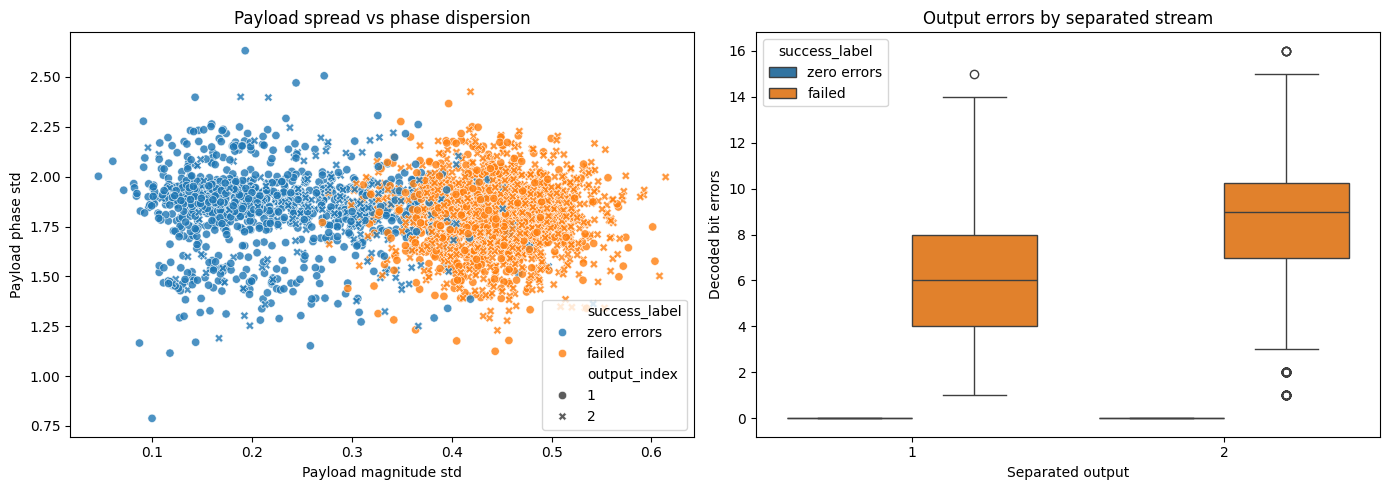

In [ ]:
if sep_output_df.empty:
    print("Skipping output-level recovery analysis because sep_output_df is empty.")
else:
    output_plot_df = sep_output_df.copy()
    output_plot_df["success_label"] = output_plot_df["success"].map({0: "failed", 1: "zero errors"})

    print("Grouped output summaries:")
    output_summary = (
        output_plot_df
        .groupby(["output_index", "success"], as_index=False)
        .agg(
            n_rows=("frame_number", "count"),
            mean_errors=("numErrors", "mean"),
            median_errors=("numErrors", "median"),
            mean_payload_std_abs=("payload_std_abs", "mean"),
            mean_payload_phase_std=("payload_phase_std", "mean"),
        )
    )
    display(output_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(
        data=output_plot_df,
        x="payload_std_abs",
        y="payload_phase_std",
        hue="success_label",
        style="output_index",
        alpha=0.8,
        ax=axes[0],
    )
    axes[0].set_title("Payload spread vs phase dispersion")
    axes[0].set_xlabel("Payload magnitude std")
    axes[0].set_ylabel("Payload phase std")

    sns.boxplot(data=output_plot_df, x="output_index", y="numErrors", hue="success_label", ax=axes[1])
    axes[1].set_title("Output errors by separated stream")
    axes[1].set_xlabel("Separated output")
    axes[1].set_ylabel("Decoded bit errors")

    plt.tight_layout()
    plt.show()

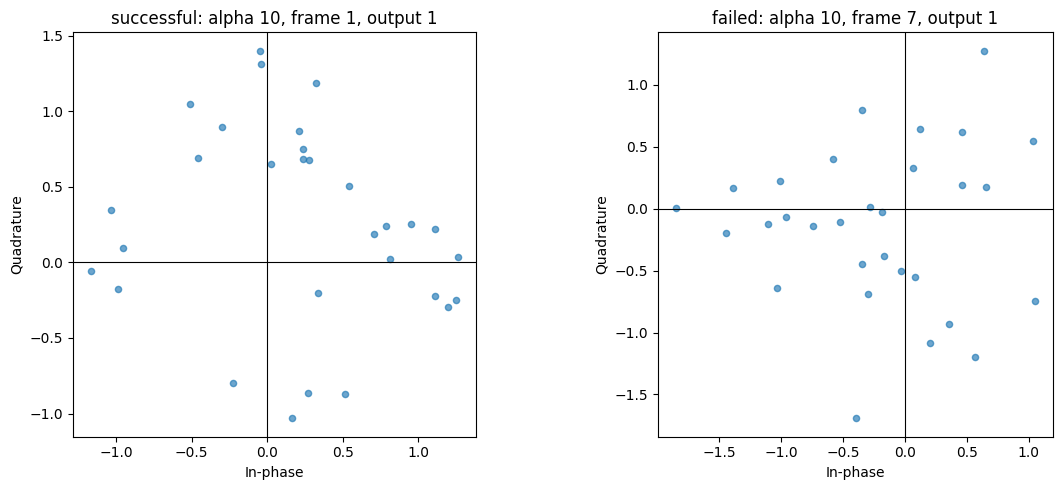

In [ ]:
def debug_field(debug_obj, name, default=None):
    if isinstance(debug_obj, dict):
        return debug_obj.get(name, default)
    return getattr(debug_obj, name, default)

def payload_at(payload_cells, frame_idx, output_idx):
    try:
        return np.asarray(payload_cells[frame_idx, output_idx]).ravel()
    except Exception:
        return np.asarray(payload_cells[frame_idx][output_idx]).ravel()

def find_constellation_example(target_success=None):
    for mat_path in debug_mat_files:
        try:
            debug_obj = loadmat(mat_path, squeeze_me=True, simplify_cells=True)["debugOut"]
            success_vec = np.asarray(debug_field(debug_obj, "success")).astype(int).ravel()
            best_outputs = np.asarray(debug_field(debug_obj, "bestOutputIndex")).astype(int).ravel()
            payload_cells = debug_field(debug_obj, "rxSymsPayload")
            alpha_index = int(np.asarray(debug_field(debug_obj, "alphaIndex")).ravel()[0])

            for frame_idx, success_val in enumerate(success_vec):
                if target_success is None or success_val == target_success:
                    output_idx = max(0, best_outputs[frame_idx] - 1)
                    payload = payload_at(payload_cells, frame_idx, output_idx)
                    return {
                        "mat_path": mat_path,
                        "alphaIndex": alpha_index,
                        "frame_number": frame_idx + 1,
                        "output_index": output_idx + 1,
                        "success": int(success_val),
                        "payload": payload,
                    }
        except Exception as exc:
            print(f"Could not inspect {mat_path.name}: {exc}")
    return None

if not debug_mat_files:
    print("No debug MAT files available for constellation inspection.")
else:
    examples = [find_constellation_example(1), find_constellation_example(0)]
    examples = [example for example in examples if example is not None]

    if not examples:
        print("No constellation examples could be extracted from the debug MAT files.")
    else:
        fig, axes = plt.subplots(1, len(examples), figsize=(6 * len(examples), 5))
        if len(examples) == 1:
            axes = [axes]

        for ax, example in zip(axes, examples):
            payload = example["payload"]
            ax.scatter(payload.real, payload.imag, s=20, alpha=0.65)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_aspect("equal", adjustable="box")
            label = "successful" if example["success"] == 1 else "failed"
            ax.set_title(
                f"{label}: alpha {example['alphaIndex']}, frame {example['frame_number']}, output {example['output_index']}"
            )
            ax.set_xlabel("In-phase")
            ax.set_ylabel("Quadrature")

        plt.tight_layout()
        plt.show()

# Part D: Learned Separator MIT Evaluation

This section reads MIT debug-evaluation outputs for the FastICA baseline and learned separator runs. It keeps the backend evaluation chain unchanged: learned models write MIT-compatible `outputA` / `outputB` files, then Octave produces the same per-frame, per-output, and MAT debug artifacts used above.


In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

challenge_root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge")
merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
feature_path = challenge_root / "separation_frame_features.csv"

baseline_debug_dir = challenge_root / "debugEval"
learned_debug_dirs = sorted(challenge_root.glob("debugEval_learned_*"))
mit_debug_sources = [("FastICA", baseline_debug_dir)] + [
    (path.name.replace("debugEval_learned_", "Learned: "), path)
    for path in learned_debug_dirs
]

def normalize_key_columns(table):
    for col in merge_keys + ["success", "best_output_index", "output_index"]:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")
    return table

def load_debug_table(paths, separator):
    tables = []
    for path in paths:
        try:
            table = pd.read_csv(path)
            table["separator"] = separator
            table["source_file"] = path.name
            tables.append(normalize_key_columns(table))
        except Exception as exc:
            print(f"Could not read {path}: {exc}")
    return pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

def load_summary_table(path, separator):
    if not path.exists():
        return pd.DataFrame()
    try:
        summary = pd.read_csv(path)
        summary["separator"] = separator
        return summary
    except Exception as exc:
        print(f"Could not read {path}: {exc}")
        return pd.DataFrame()

frame_tables = []
output_tables = []
summary_tables = []
for separator, debug_dir in mit_debug_sources:
    if not debug_dir.exists():
        print(f"Missing debug directory for {separator}: {debug_dir}")
        continue
    per_frame_files = sorted(debug_dir.glob("*_perFrame.csv"))
    per_output_files = sorted(debug_dir.glob("*_perOutput.csv"))
    print(f"{separator}: {len(per_frame_files)} per-frame CSVs, {len(per_output_files)} per-output CSVs")
    frame_tables.append(load_debug_table(per_frame_files, separator))
    output_tables.append(load_debug_table(per_output_files, separator))
    summary_tables.append(load_summary_table(debug_dir / "debug_run_summary.csv", separator))

mit_eval_frame_df = pd.concat([table for table in frame_tables if not table.empty], ignore_index=True) if frame_tables else pd.DataFrame()
mit_eval_output_df = pd.concat([table for table in output_tables if not table.empty], ignore_index=True) if output_tables else pd.DataFrame()
mit_eval_summary_df = pd.concat([table for table in summary_tables if not table.empty], ignore_index=True) if summary_tables else pd.DataFrame()

frame_feature_df_mit = pd.read_csv(feature_path) if feature_path.exists() else pd.DataFrame()
if not frame_feature_df_mit.empty:
    frame_feature_df_mit = normalize_key_columns(frame_feature_df_mit)

if not mit_eval_frame_df.empty and not frame_feature_df_mit.empty:
    mit_recovery_feature_df = mit_eval_frame_df.merge(frame_feature_df_mit, on=merge_keys, how="inner")
else:
    mit_recovery_feature_df = pd.DataFrame()

print("mit_eval_frame_df shape:", mit_eval_frame_df.shape)
print("mit_eval_output_df shape:", mit_eval_output_df.shape)
print("mit_eval_summary_df shape:", mit_eval_summary_df.shape)
print("frame_feature_df_mit shape:", frame_feature_df_mit.shape)
print("mit_recovery_feature_df shape:", mit_recovery_feature_df.shape)

if not mit_eval_frame_df.empty:
    print("Frame columns:")
    print(list(mit_eval_frame_df.columns))
    print("Success counts by separator:")
    display(mit_eval_frame_df.groupby("separator")["success"].value_counts(dropna=False).unstack(fill_value=0))
    display(mit_eval_frame_df.head())

if not mit_eval_output_df.empty:
    print("Output columns:")
    print(list(mit_eval_output_df.columns))
    display(mit_eval_output_df.head())


FastICA: 15 per-frame CSVs, 15 per-output CSVs
Learned: Hybrid: 5 per-frame CSVs, 5 per-output CSVs
mit_eval_frame_df shape: (2000, 9)
mit_eval_output_df shape: (4000, 13)
mit_eval_summary_df shape: (20, 6)
frame_feature_df_mit shape: (1500, 51)
mit_recovery_feature_df shape: (2000, 56)
Frame columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'best_output_index', 'best_num_errors', 'success', 'separator', 'source_file']
Success counts by separator:


success,0,1
separator,,
FastICA,280,1220
Learned: Hybrid,500,0


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,separator,source_file
0,10,4,1,1,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
1,10,4,1,2,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
2,10,4,1,3,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
3,10,4,1,4,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
4,10,4,1,5,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv


Output columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'output_index', 'numErrors', 'success', 'payload_mean_abs', 'payload_std_abs', 'payload_phase_std', 'payload_power_mean', 'separator', 'source_file']


,alphaIndex,frameLen,setIndex,frame_number,output_index,numErrors,success,payload_mean_abs,payload_std_abs,payload_phase_std,payload_power_mean,separator,source_file
0,10,4,1,1,1,0,1,0.973549,0.232385,1.529508,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
1,10,4,1,1,2,7,0,0.873792,0.494613,1.956597,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
2,10,4,1,2,1,0,1,0.984177,0.180218,2.153285,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
3,10,4,1,2,2,4,0,0.925038,0.386369,2.179054,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
4,10,4,1,3,1,0,1,0.987049,0.163165,1.851892,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv


,separator,alphaIndex,frame_success_rate,mean_best_errors,n_frames,ber
0,FastICA,1,0.91,0.26,100,0.0130
1,FastICA,2,0.84,0.72,100,0.0360
2,FastICA,3,0.91,0.41,100,0.0205
3,FastICA,4,0.89,0.61,100,0.0305
4,FastICA,5,0.84,0.77,100,0.0385
5,FastICA,6,0.91,0.37,100,0.0185
6,FastICA,7,0.81,0.78,100,0.0390
7,FastICA,8,0.91,0.31,100,0.0155
8,FastICA,9,0.85,0.53,100,0.0265
9,FastICA,10,0.84,0.59,100,0.0295


Compact comparison over common alphaIndex values: [1, 2, 3, 4, 5]


,separator,frame_success_rate,mean_best_errors,n_frames,alpha_min,alpha_max,mean_ber
0,FastICA,0.878,0.554,500,1,5,0.0277
1,Learned: Hybrid,0.0,8.778,500,1,5,0.4389


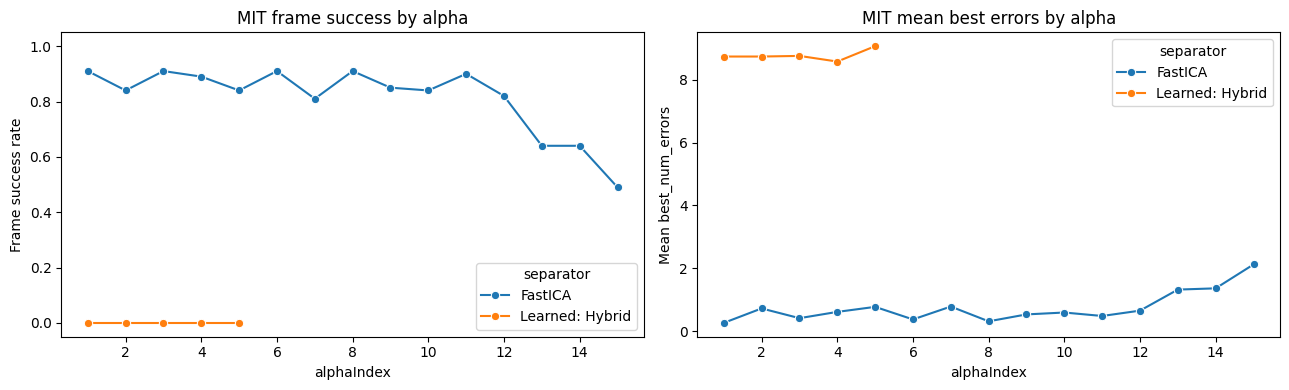

In [ ]:
learned_alpha_summary = pd.DataFrame()
mit_separator_results = pd.DataFrame()

if mit_eval_frame_df.empty:
    print("Skipping learned-separator comparison because no MIT debug frame rows were found.")
else:
    learned_alpha_summary = (
        mit_eval_frame_df
        .groupby(["separator", "alphaIndex"], dropna=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
        )
        .reset_index()
    )

    if not mit_eval_summary_df.empty and "ber" in mit_eval_summary_df.columns:
        ber_by_alpha = mit_eval_summary_df[["separator", "alphaIndex", "ber"]].copy()
        learned_alpha_summary = learned_alpha_summary.merge(
            ber_by_alpha,
            on=["separator", "alphaIndex"],
            how="left",
        )

    display(learned_alpha_summary.round(4))

    alpha_sets = [set(group["alphaIndex"].dropna().astype(int)) for _, group in mit_eval_frame_df.groupby("separator")]
    common_alphas = sorted(set.intersection(*alpha_sets)) if len(alpha_sets) > 1 else sorted(alpha_sets[0])
    comparison_scope = mit_eval_frame_df[mit_eval_frame_df["alphaIndex"].astype(int).isin(common_alphas)].copy()

    mit_separator_results = (
        comparison_scope
        .groupby("separator", dropna=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
            alpha_min=("alphaIndex", "min"),
            alpha_max=("alphaIndex", "max"),
        )
        .reset_index()
    )

    if not mit_eval_summary_df.empty and "ber" in mit_eval_summary_df.columns and common_alphas:
        ber_scope = mit_eval_summary_df[mit_eval_summary_df["alphaIndex"].astype(int).isin(common_alphas)]
        ber_summary = ber_scope.groupby("separator", dropna=False).agg(mean_ber=("ber", "mean")).reset_index()
        mit_separator_results = mit_separator_results.merge(ber_summary, on="separator", how="left")

    print(f"Compact comparison over common alphaIndex values: {common_alphas}")
    display(mit_separator_results.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.lineplot(data=learned_alpha_summary, x="alphaIndex", y="frame_success_rate", hue="separator", marker="o", ax=axes[0])
    axes[0].set_title("MIT frame success by alpha")
    axes[0].set_ylabel("Frame success rate")
    axes[0].set_ylim(-0.05, 1.05)

    sns.lineplot(data=learned_alpha_summary, x="alphaIndex", y="mean_best_errors", hue="separator", marker="o", ax=axes[1])
    axes[1].set_title("MIT mean best errors by alpha")
    axes[1].set_ylabel("Mean best_num_errors")
    plt.tight_layout()
    plt.show()


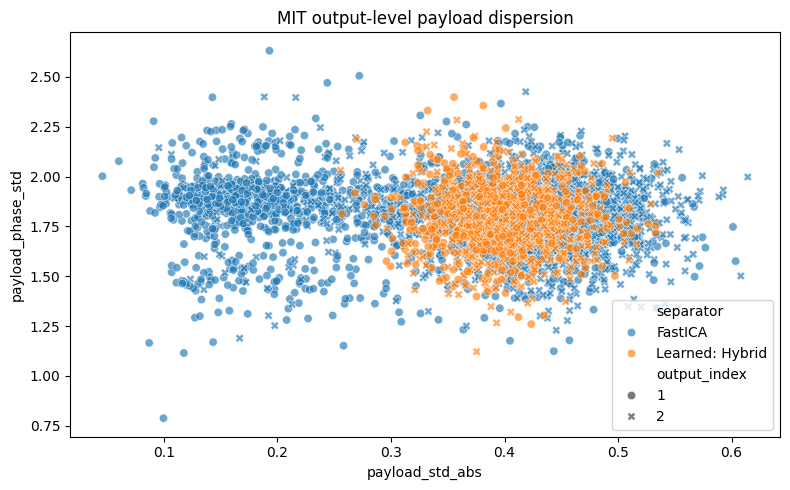

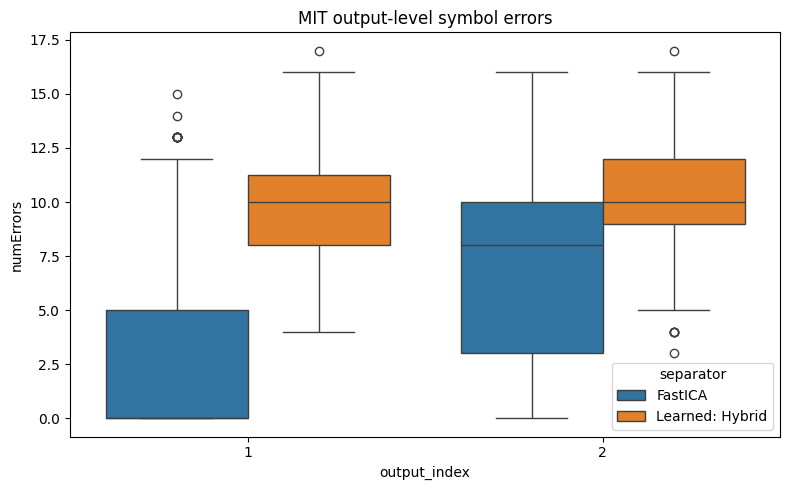

,separator,output_index,success,n_outputs,mean_numErrors,mean_payload_std_abs,mean_payload_phase_std
0,FastICA,1,0,564,6.1667,0.4286,1.7906
1,FastICA,1,1,936,0.0000,0.2085,1.8393
2,FastICA,2,0,1204,8.3829,0.4497,1.8022
3,FastICA,2,1,296,0.0000,0.2702,1.8339
4,Learned: Hybrid,1,0,500,9.9540,0.3933,1.8019
5,Learned: Hybrid,2,0,500,10.0200,0.4055,1.7854


In [ ]:
if mit_eval_output_df.empty:
    print("Skipping learned output-level plots because no per-output rows were found.")
else:
    available_cols = set(mit_eval_output_df.columns)
    if {"payload_std_abs", "payload_phase_std", "success", "output_index", "separator"}.issubset(available_cols):
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=mit_eval_output_df,
            x="payload_std_abs",
            y="payload_phase_std",
            hue="separator",
            style="output_index",
            alpha=0.65,
        )
        plt.title("MIT output-level payload dispersion")
        plt.tight_layout()
        plt.show()

    if {"numErrors", "output_index", "separator"}.issubset(available_cols):
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=mit_eval_output_df, x="output_index", y="numErrors", hue="separator")
        plt.title("MIT output-level symbol errors")
        plt.tight_layout()
        plt.show()

    grouped_output_summary = (
        mit_eval_output_df
        .groupby(["separator", "output_index", "success"], dropna=False)
        .agg(
            n_outputs=("frame_number", "count"),
            mean_numErrors=("numErrors", "mean"),
            mean_payload_std_abs=("payload_std_abs", "mean"),
            mean_payload_phase_std=("payload_phase_std", "mean"),
        )
        .reset_index()
    )
    display(grouped_output_summary.round(4))


In [ ]:
learned_recovery_model_results = pd.DataFrame()

if mit_recovery_feature_df.empty:
    print("Skipping learned recovery-side model check because merged frame features are unavailable.")
else:
    learned_rows = mit_recovery_feature_df[mit_recovery_feature_df["separator"].astype(str).str.startswith("Learned")].copy()
    if learned_rows.empty:
        print("No learned separator rows found in mit_recovery_feature_df.")
    else:
        excluded_cols = set(merge_keys + ["success", "best_num_errors", "best_output_index"])
        excluded_cols.update(["separator", "source_file"])
        feature_cols_learned = [
            col for col in learned_rows.select_dtypes(include=[np.number]).columns
            if col not in excluded_cols
        ]
        X_learned = learned_rows[feature_cols_learned].replace([np.inf, -np.inf], np.nan).dropna(axis=0)
        y_learned = learned_rows.loc[X_learned.index, "success"].astype(int)

        if X_learned.empty or len(feature_cols_learned) < 2:
            print("Not enough learned rows/features for recovery-side modeling.")
        elif y_learned.nunique() < 2 or y_learned.value_counts().min() < 2:
            print("Learned separator classification skipped because success labels are one-class or too imbalanced.")
            error_corr = (
                learned_rows[feature_cols_learned + ["best_num_errors"]]
                .corr(numeric_only=True)["best_num_errors"]
                .drop("best_num_errors")
                .sort_values(key=lambda s: s.abs(), ascending=False)
                .head(12)
            )
            print("Fallback: strongest absolute correlations with best_num_errors for learned rows")
            display(error_corr.to_frame("corr_with_best_num_errors"))
        else:
            X_scaled = StandardScaler().fit_transform(X_learned)
            n_splits = min(5, int(y_learned.value_counts().min()))
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            models = {
                "LDA": LinearDiscriminantAnalysis(),
                "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
                "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
            }
            rows = []
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                for name, model in models.items():
                    scores = cross_val_score(model, X_scaled, y_learned, cv=cv, scoring="accuracy")
                    rows.append({
                        "Model": name,
                        "Mean CV Accuracy": scores.mean(),
                        "Std CV Accuracy": scores.std(),
                    })
            learned_recovery_model_results = pd.DataFrame(rows).round(4)
            display(learned_recovery_model_results)


Learned separator classification skipped because success labels are one-class or too imbalanced.
Fallback: strongest absolute correlations with best_num_errors for learned rows


,corr_with_best_num_errors
coherence_max,-0.099637
coherence_std,-0.083549
offdiag_cov_abs_max,-0.076456
offdiag_cov_abs_std,-0.072943
cov_eig_2,0.069827
cov_eig_1,-0.062810
cov_condition,-0.059509
power_std,0.055090
ch4_papr,-0.054603
ch3_amp_std,0.054493


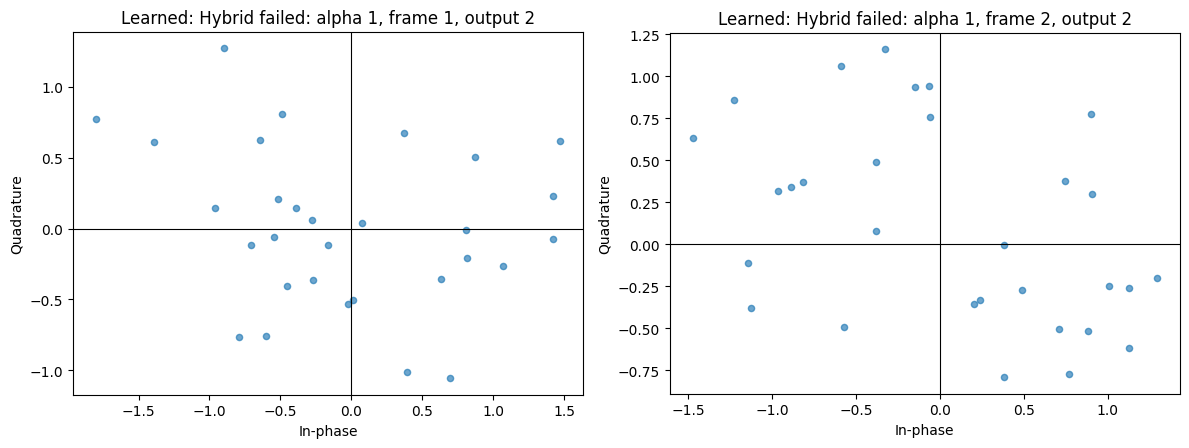

In [ ]:
def debug_field(debug_obj, name, default=None):
    if isinstance(debug_obj, dict):
        return debug_obj.get(name, default)
    return getattr(debug_obj, name, default)

def payload_at(payload_cells, frame_idx, output_idx):
    try:
        return np.asarray(payload_cells[frame_idx, output_idx]).ravel()
    except Exception:
        return np.asarray(payload_cells[frame_idx][output_idx]).ravel()

def find_learned_constellation_examples(max_examples=2):
    examples = []
    for debug_dir in learned_debug_dirs:
        for mat_path in sorted(debug_dir.glob("*_debug.mat")):
            try:
                debug_obj = loadmat(mat_path, squeeze_me=True, simplify_cells=True)["debugOut"]
                success_vec = np.asarray(debug_field(debug_obj, "success", [])).astype(int).ravel()
                best_outputs = np.asarray(debug_field(debug_obj, "bestOutputIndex", [])).astype(int).ravel()
                payload_cells = debug_field(debug_obj, "rxSymsPayload")
                alpha_index = int(np.asarray(debug_field(debug_obj, "alphaIndex", 0)).ravel()[0])

                for frame_idx, success_val in enumerate(success_vec):
                    output_idx = max(0, best_outputs[frame_idx] - 1) if frame_idx < len(best_outputs) else 0
                    payload = payload_at(payload_cells, frame_idx, output_idx)
                    examples.append({
                        "separator": debug_dir.name.replace("debugEval_learned_", "Learned: "),
                        "mat_path": mat_path,
                        "alphaIndex": alpha_index,
                        "frame_number": frame_idx + 1,
                        "output_index": output_idx + 1,
                        "success": int(success_val),
                        "payload": payload,
                    })
                    if len(examples) >= max_examples:
                        return examples
            except Exception as exc:
                print(f"Could not inspect {mat_path.name}: {exc}")
    return examples

learned_constellation_examples = find_learned_constellation_examples(max_examples=2)

if not learned_constellation_examples:
    print("No learned debug MAT constellations were available.")
else:
    fig, axes = plt.subplots(1, len(learned_constellation_examples), figsize=(6 * len(learned_constellation_examples), 5))
    if len(learned_constellation_examples) == 1:
        axes = [axes]

    for ax, example in zip(axes, learned_constellation_examples):
        payload = example["payload"]
        ax.scatter(payload.real, payload.imag, s=20, alpha=0.65)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_aspect("equal", adjustable="box")
        label = "successful" if example["success"] == 1 else "failed"
        ax.set_title(
            f"{example['separator']} {label}: alpha {example['alphaIndex']}, frame {example['frame_number']}, output {example['output_index']}"
        )
        ax.set_xlabel("In-phase")
        ax.set_ylabel("Quadrature")

    plt.tight_layout()
    plt.show()


## TODO: MIT-aligned synthetic generator mode

Next improvement stage:

- Train and evaluate with `n_rx = 4` so learned checkpoints can consume all MIT receiver streams directly.
- Match MIT-like frame settings, especially short `frameLen = 4` recovery examples.
- Add structured phase-only mixing options instead of only the current synthetic mixing assumptions.
- Sweep a broader MIT-like alpha and noise range.
- Add optional interferer diversity closer to the MIT backend mixtures.


# Part E: Synthetic Benchmark Expansion

This section loads benchmark outputs from the expanded synthetic generator and benchmark runner. The files are machine-readable CSV/JSON artifacts produced under `reporting_pipeline/outputs/benchmarks`, so the notebook can refresh without rerunning training or evaluation.


In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path(r"D:\CS 6955\CS-6955\DL-AIR")
benchmark_root = project_root / "reporting_pipeline" / "outputs" / "benchmarks"

model_result_files = sorted(benchmark_root.glob("*/synthetic_model_results.csv"))
classical_result_files = sorted(benchmark_root.glob("*/classical_feature_results.csv"))
feature_example_files = sorted(benchmark_root.glob("*/synthetic_feature_examples.csv"))
summary_files = sorted(benchmark_root.glob("*/benchmark_summary.json"))

synthetic_model_results = pd.concat([pd.read_csv(path) for path in model_result_files], ignore_index=True) if model_result_files else pd.DataFrame()
classical_feature_results = pd.concat([pd.read_csv(path) for path in classical_result_files], ignore_index=True) if classical_result_files else pd.DataFrame()
synthetic_feature_examples = pd.concat([pd.read_csv(path) for path in feature_example_files], ignore_index=True) if feature_example_files else pd.DataFrame()

print("benchmark root:", benchmark_root)
print("model result files:", len(model_result_files))
print("classical result files:", len(classical_result_files))
print("feature example files:", len(feature_example_files))
print("synthetic_model_results shape:", synthetic_model_results.shape)
print("classical_feature_results shape:", classical_feature_results.shape)
print("synthetic_feature_examples shape:", synthetic_feature_examples.shape)

if synthetic_model_results.empty:
    print("No synthetic benchmark model results found yet. Run run_rf_benchmarks.py to populate this section.")
else:
    display(synthetic_model_results)

if not classical_feature_results.empty:
    display(classical_feature_results)


benchmark root: D:\CS 6955\CS-6955\DL-AIR\reporting_pipeline\outputs\benchmarks
model result files: 1
classical result files: 1
feature example files: 1
synthetic_model_results shape: (6, 11)
classical_feature_results shape: (3, 7)
synthetic_feature_examples shape: (40, 42)


,benchmark,model,model_type,mode,n_rx,num_examples,mse,sdr_db,symbol_accuracy,checkpoint_path,status
0,benchmark_modulation_diverse,FastICA,classical_separator,evaluate,2,4,1.248074,-3.885687,NaN,NaN,ok
1,benchmark_modulation_diverse,Hybrid,neural,evaluate,2,4,0.625357,-0.916656,NaN,D:\CS 6955\CS-6955\DL-AIR\pytorch_models\hybri...,ok
2,benchmark_modulation_diverse,LSTM,neural,evaluate,2,4,0.598301,-0.723372,NaN,D:\CS 6955\CS-6955\DL-AIR\pytorch_models\lstm_...,ok
3,benchmark_modulation_diverse,Linear,neural,evaluate,2,4,NaN,NaN,NaN,NaN,missing_checkpoint
4,benchmark_modulation_diverse,IQ_CNN,neural,evaluate,2,4,0.659114,-1.128065,NaN,D:\CS 6955\CS-6955\DL-AIR\pytorch_models\iq_cn...,ok
5,benchmark_modulation_diverse,HTDemucs,neural,evaluate,2,4,0.554644,-0.451641,NaN,D:\CS 6955\CS-6955\DL-AIR\pytorch_models\htdem...,ok


,benchmark,model,model_type,task,mean_cv_accuracy,std_cv_accuracy,status
0,benchmark_modulation_diverse,LDA,classical_feature,source_b_type,0.200,0.150000,ok
1,benchmark_modulation_diverse,QDA,classical_feature,source_b_type,0.300,0.100000,ok
2,benchmark_modulation_diverse,Logistic Regression,classical_feature,source_b_type,0.325,0.061237,ok


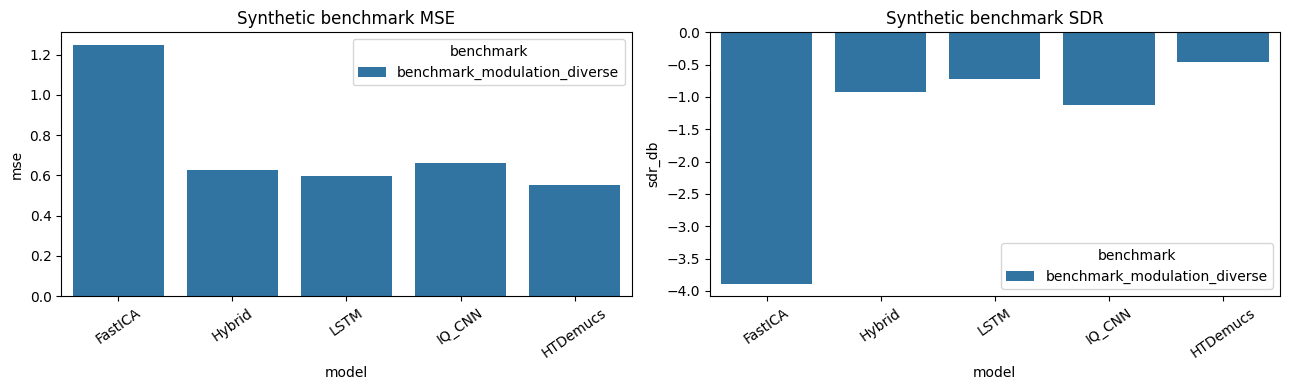

Benchmark status table:


,benchmark,model,status,rows
0,benchmark_modulation_diverse,FastICA,ok,1
1,benchmark_modulation_diverse,HTDemucs,ok,1
2,benchmark_modulation_diverse,Hybrid,ok,1
3,benchmark_modulation_diverse,IQ_CNN,ok,1
4,benchmark_modulation_diverse,LSTM,ok,1
5,benchmark_modulation_diverse,Linear,missing_checkpoint,1


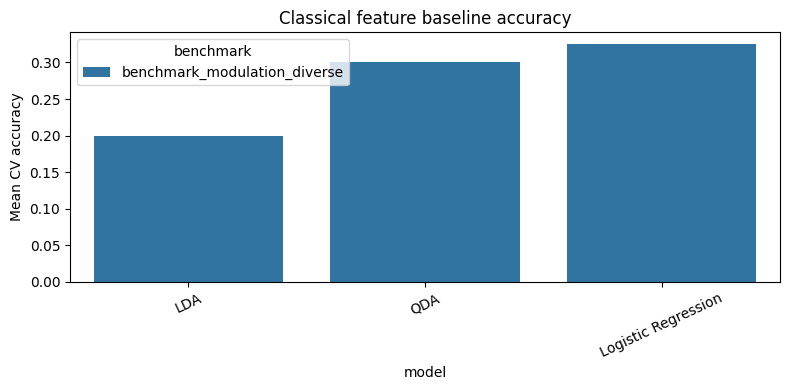

In [ ]:
if synthetic_model_results.empty:
    print("Skipping synthetic benchmark plots because no model results were found.")
else:
    plot_df = synthetic_model_results.copy()
    plot_df["model_status"] = plot_df["model"] + " (" + plot_df["status"].astype(str) + ")"
    ok_df = plot_df[plot_df["status"].astype(str).str.startswith("ok")].copy()

    if ok_df.empty:
        print("No successful model rows available for plotting.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        sns.barplot(data=ok_df, x="model", y="mse", hue="benchmark", ax=axes[0])
        axes[0].set_title("Synthetic benchmark MSE")
        axes[0].tick_params(axis="x", rotation=35)

        sns.barplot(data=ok_df, x="model", y="sdr_db", hue="benchmark", ax=axes[1])
        axes[1].set_title("Synthetic benchmark SDR")
        axes[1].tick_params(axis="x", rotation=35)
        plt.tight_layout()
        plt.show()

    status_table = (
        synthetic_model_results
        .groupby(["benchmark", "model", "status"], dropna=False)
        .size()
        .reset_index(name="rows")
    )
    print("Benchmark status table:")
    display(status_table)

if classical_feature_results.empty:
    print("No classical feature baseline rows found yet.")
else:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=classical_feature_results, x="model", y="mean_cv_accuracy", hue="benchmark")
    plt.title("Classical feature baseline accuracy")
    plt.ylabel("Mean CV accuracy")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()


## Expanded Generator And Benchmark Notes

The synthetic backend now supports the original QPSK/QPSK path plus BPSK, 8-PSK, 16-QAM, PAM/ASK-style symbols, multitone/OFDM-like interferers, colored noise, chirps, bursty interferers, and a recorded-interferer placeholder. Benchmark presets include QPSK baseline, modulation-diverse, multichannel phase-only, MIT-aligned, and interferer-diverse settings.

Current limitation: the legacy symbol-accuracy evaluator is QPSK-specific, so modulation-diverse benchmark tables report MSE/SDR for all models while keeping symbol accuracy blank unless a QPSK-compatible evaluation path is used. MIT transfer also still depends on checkpoints whose receiver count and frame assumptions match the MIT backend.


# Part F: Unsupervised Learning On MIT Multichannel Mixtures

This section shifts attention from separator outputs back to the **actual multichannel MIT mixtures themselves**. The goal is to understand whether the four-channel mixture geometry contains latent low-dimensional structure that tracks difficulty, recovery success, and separator behavior.

The working hypothesis is that the dominant variance in these short multichannel RF frames is not purely random. Instead, it may reflect a combination of amplitude balance, spatial covariance geometry, inter-channel coherence, phase alignment, and spectral concentration. If that is true, then unsupervised structure in the mixture space should help explain why some frames are easy to separate and decode while others are persistently difficult.


In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import FactorAnalysis, FastICA as SkFastICA, PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.manifold import Isomap, LocallyLinearEmbedding, TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import umap
except Exception:
    umap = None

challenge_root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge")
analysis_output_root = challenge_root / "analysis_outputs"
figure_output_root = analysis_output_root / "figures"
analysis_output_root.mkdir(parents=True, exist_ok=True)
figure_output_root.mkdir(parents=True, exist_ok=True)

merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
expected_separator_names = ["FastICA", "Learned: Hybrid", "Learned: LSTM", "Learned: Linear", "Learned: IQ_CNN", "Learned: HTDemucs"]


def feature_family(name):
    name = str(name)
    if any(token in name for token in ["amp", "power", "papr", "radius", "iq_kurtosis", "iq_skewness"]):
        return "amplitude"
    if any(token in name for token in ["cov_", "eig", "condition", "participation"]):
        return "covariance"
    if any(token in name for token in ["coherence", "offdiag"]):
        return "coherence"
    if "phase" in name:
        return "phase"
    if "spec_" in name:
        return "spectral"
    if name in merge_keys or name in {"source_path", "separator", "source_file"}:
        return "metadata"
    return "other"


def flatten_columns(frame):
    if not isinstance(frame.columns, pd.MultiIndex):
        return frame
    frame = frame.copy()
    frame.columns = [
        "_".join(str(part) for part in col if str(part) != "")
        for col in frame.columns.to_flat_index()
    ]
    return frame


def normalize_key_columns(table):
    table = table.copy()
    for col in merge_keys + ["success", "best_output_index", "output_index"]:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")
    return table


def load_debug_tables(debug_sources):
    frame_tables = []
    output_tables = []
    summary_tables = []
    for separator, debug_dir in debug_sources:
        if not debug_dir.exists():
            continue
        per_frame_files = sorted(debug_dir.glob("*_perFrame.csv"))
        per_output_files = sorted(debug_dir.glob("*_perOutput.csv"))
        if per_frame_files:
            per_frames = []
            for path in per_frame_files:
                table = pd.read_csv(path)
                table["separator"] = separator
                table["source_file"] = path.name
                per_frames.append(table)
            frame_tables.append(normalize_key_columns(pd.concat(per_frames, ignore_index=True)))
        if per_output_files:
            per_outputs = []
            for path in per_output_files:
                table = pd.read_csv(path)
                table["separator"] = separator
                table["source_file"] = path.name
                per_outputs.append(table)
            output_tables.append(normalize_key_columns(pd.concat(per_outputs, ignore_index=True)))
        summary_path = debug_dir / "debug_run_summary.csv"
        if summary_path.exists():
            summary = pd.read_csv(summary_path)
            summary["separator"] = separator
            summary_tables.append(summary)
    frame_df = pd.concat(frame_tables, ignore_index=True) if frame_tables else pd.DataFrame()
    output_df = pd.concat(output_tables, ignore_index=True) if output_tables else pd.DataFrame()
    summary_df = pd.concat(summary_tables, ignore_index=True) if summary_tables else pd.DataFrame()
    return frame_df, output_df, summary_df


def save_table(frame, filename):
    path = analysis_output_root / filename
    frame.to_csv(path, index=False)
    print(f"Saved table to {path}")
    return path


def save_figure(fig, filename):
    path = figure_output_root / filename
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved figure to {path}")
    return path


def numeric_feature_columns(frame, extra_exclude=None, min_non_null=0.98):
    exclude = set(extra_exclude or [])
    cols = []
    for col in frame.select_dtypes(include=[np.number]).columns:
        if col in exclude:
            continue
        if frame[col].notna().mean() >= min_non_null:
            cols.append(col)
    return cols


def top_feature_list(frame, feature_cols, n=18):
    var = frame[feature_cols].replace([np.inf, -np.inf], np.nan).var(numeric_only=True).sort_values(ascending=False)
    return list(var.head(n).index)


extended_feature_path = challenge_root / "separation_frame_features_extended.csv"
fallback_feature_path = challenge_root / "separation_frame_features.csv"
feature_path_in_use = extended_feature_path if extended_feature_path.exists() else fallback_feature_path
mit_feature_table = pd.read_csv(feature_path_in_use)
mit_feature_table = normalize_key_columns(mit_feature_table)

separator_sources = [("FastICA", challenge_root / "debugEval")] + [
    (path.name.replace("debugEval_learned_", "Learned: "), path)
    for path in sorted(challenge_root.glob("debugEval_learned_*"))
]
separator_frame_long_df, separator_output_long_df, separator_summary_df = load_debug_tables(separator_sources)

available_separators = sorted(separator_frame_long_df["separator"].dropna().unique()) if not separator_frame_long_df.empty else []
missing_expected_separators = [name for name in expected_separator_names if name not in available_separators]

fastica_frame_labels_df = (
    separator_frame_long_df[separator_frame_long_df["separator"] == "FastICA"].copy()
    if not separator_frame_long_df.empty else pd.DataFrame()
)
fastica_keep_cols = merge_keys + [col for col in ["best_output_index", "best_num_errors", "success", "separator", "source_file"] if col in fastica_frame_labels_df.columns]
fastica_frame_labels_df = fastica_frame_labels_df[fastica_keep_cols].drop_duplicates(subset=merge_keys) if not fastica_frame_labels_df.empty else pd.DataFrame()

fastica_feature_df = mit_feature_table.merge(
    fastica_frame_labels_df.drop(columns=["separator"], errors="ignore"),
    on=merge_keys,
    how="left",
)
separator_feature_long_df = separator_frame_long_df.merge(mit_feature_table, on=merge_keys, how="left") if not separator_frame_long_df.empty else pd.DataFrame()
separator_output_feature_long_df = separator_output_long_df.merge(mit_feature_table, on=merge_keys, how="left") if not separator_output_long_df.empty else pd.DataFrame()

inventory_rows = []
for col in mit_feature_table.columns:
    series = mit_feature_table[col]
    inventory_rows.append({
        "feature": col,
        "family": feature_family(col),
        "dtype": str(series.dtype),
        "non_null_fraction": float(series.notna().mean()),
        "n_unique": int(series.nunique(dropna=True)),
        "std": float(series.std()) if pd.api.types.is_numeric_dtype(series) else np.nan,
        "near_constant": bool(series.nunique(dropna=True) <= 2 or (pd.api.types.is_numeric_dtype(series) and float(series.std()) < 1e-8)),
    })
feature_inventory_df = pd.DataFrame(inventory_rows).sort_values(["family", "near_constant", "non_null_fraction", "feature"], ascending=[True, True, False, True]).reset_index(drop=True)

save_table(feature_inventory_df, "mit_multichannel_feature_inventory.csv")

missingness_df = (
    feature_inventory_df[["feature", "family", "non_null_fraction"]]
    .assign(missing_fraction=lambda d: 1.0 - d["non_null_fraction"])
    .sort_values(["missing_fraction", "feature"], ascending=[False, True])
)
constant_or_near_constant = feature_inventory_df.loc[feature_inventory_df["near_constant"], "feature"].tolist()
family_counts = feature_inventory_df.groupby("family")["feature"].count().rename("n_features").reset_index()

print("Feature path:", feature_path_in_use)
print("mit_feature_table shape:", mit_feature_table.shape)
print("separator_frame_long_df shape:", separator_frame_long_df.shape)
print("separator_output_feature_long_df shape:", separator_output_feature_long_df.shape)
print("fastica_feature_df shape:", fastica_feature_df.shape)
print("Available separators:", available_separators)
print("Missing expected separators:", missing_expected_separators)
print("Near-constant columns:", constant_or_near_constant[:12], "..." if len(constant_or_near_constant) > 12 else "")
print("Top missing columns:")
display(missingness_df.head(15))
print("Feature inventory by family:")
display(family_counts)
print("Feature inventory sample:")
display(feature_inventory_df.head(20))


## Multichannel Geometry Roadmap

The exploratory workflow below deliberately moves from coarse summaries to progressively richer structure discovery.

1. **Feature sanity checks and grouped summaries** tell us whether the four-channel mixtures differ mostly in raw power, spatial covariance, phase relationships, or spectral concentration.
2. **PCA / factor-style methods** test whether a small number of latent axes explains most of the variation. If the first few components are interpretable, that is evidence that the mixtures occupy a structured low-dimensional subspace rather than a feature cloud with no stable geometry.
3. **Nonlinear embeddings** ask whether the data look more like a curved manifold than a linear subspace.
4. **Clustering and density analysis** test whether there are discrete regimes, or whether difficulty changes more smoothly along a trajectory.

In RF terms, the main question is whether "easy" and "hard" mixtures differ in ways that are visible before separation: stronger inter-channel coherence, cleaner covariance geometry, better power balance, or sharper spectral structure would all be plausible markers of recoverability.


In [ ]:
unsup_feature_cols = numeric_feature_columns(
    mit_feature_table,
    extra_exclude=merge_keys + ["source_path"],
    min_non_null=0.98,
)

candidate_unsup_features = [
    "power_imbalance", "amp_std_all", "papr_mean",
    "cov_condition", "cov_spectral_entropy", "cov_participation_ratio",
    "coherence_mean", "offdiag_cov_abs_mean", "offdiag_cov_phase_std",
    "phase_diff_std_mean", "phase_diff_resultant_mean",
    "spec_entropy_mean", "spec_flatness_mean", "spec_rolloff_85_mean", "spec_bandwidth_mean",
]
selected_unsup_features = [col for col in candidate_unsup_features if col in mit_feature_table.columns][:10]
if len(selected_unsup_features) < 6:
    selected_unsup_features = top_feature_list(mit_feature_table, unsup_feature_cols, n=8)

print("Using", len(unsup_feature_cols), "numeric multichannel features for unsupervised analysis.")
print("Selected exploratory features:", selected_unsup_features)

alpha_summary_features = (
    mit_feature_table.groupby("alphaIndex")[selected_unsup_features]
    .agg(["mean", "std"])
    .pipe(flatten_columns)
    .reset_index()
)
save_table(alpha_summary_features, "mit_alpha_feature_summary.csv")

if fastica_feature_df["success"].notna().any():
    success_summary_features = (
        fastica_feature_df.dropna(subset=["success"]).groupby("success")[selected_unsup_features + ["best_num_errors"]]
        .agg(["mean", "std"])
        .pipe(flatten_columns)
        .reset_index()
    )
    save_table(success_summary_features, "mit_success_feature_summary.csv")
    print("FastICA-labeled success/failure summary:")
    display(success_summary_features)
else:
    print("No FastICA success labels were available for grouped summaries.")

if not separator_feature_long_df.empty:
    separator_summary_features = (
        separator_feature_long_df.groupby("separator")[selected_unsup_features + ["best_num_errors", "success"]]
        .agg(["mean", "std"])
        .pipe(flatten_columns)
        .reset_index()
    )
    save_table(separator_summary_features, "mit_separator_feature_summary.csv")
    print("Separator-level feature summary:")
    display(separator_summary_features)

corr_features = selected_unsup_features[:8]
if corr_features:
    corr_df = mit_feature_table[corr_features].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_df, cmap="coolwarm", center=0.0, ax=ax)
    ax.set_title("Correlation Heatmap For Selected Multichannel Features")
    fig.tight_layout()
    save_figure(fig, "mit_multichannel_correlation_heatmap.png")
    plt.show()

scatter_features = selected_unsup_features[:4]
if len(scatter_features) >= 4:
    sampled = mit_feature_table.sample(min(len(mit_feature_table), 500), random_state=42).copy()
    sampled["alpha_group"] = pd.cut(sampled["alphaIndex"].astype(int), bins=[0, 5, 15, 25], labels=["low", "mid", "high"])
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    pairings = [
        (scatter_features[0], scatter_features[1]),
        (scatter_features[0], scatter_features[2]),
        (scatter_features[1], scatter_features[3]),
        (scatter_features[2], scatter_features[3]),
    ]
    for ax, (xcol, ycol) in zip(axes.flat, pairings):
        sns.scatterplot(data=sampled, x=xcol, y=ycol, hue="alpha_group", alpha=0.7, s=35, ax=ax)
        ax.set_title(f"{xcol} vs {ycol}")
    fig.tight_layout()
    save_figure(fig, "mit_multichannel_scatter_matrix.png")
    plt.show()


## PCA, Factor Structure, And Statistical Interpretation

PCA is the most direct way to ask whether multichannel MIT frames lie near a low-dimensional linear subspace. If the first few components explain a large share of variance and have coherent loadings, those components can often be interpreted in physical terms:

- **amplitude-driven components** suggest that global energy, power imbalance, or PAPR dominates the geometry;
- **covariance-driven components** suggest that spatial anisotropy or channel mixing geometry matters;
- **coherence/phase-driven components** suggest that channel alignment is a strong latent driver;
- **spectral-driven components** suggest different interference textures or time-frequency concentration regimes.

The component summaries printed below are meant to be reusable as paper-style interpretive notes rather than just debugging output.


In [ ]:
X_unsup_raw = mit_feature_table[unsup_feature_cols].replace([np.inf, -np.inf], np.nan)
X_unsup = X_unsup_raw.fillna(X_unsup_raw.median(numeric_only=True))
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup)

n_pca_components = int(min(10, X_unsup_scaled.shape[1], X_unsup_scaled.shape[0]))
pca_model = PCA(n_components=n_pca_components, random_state=42)
pca_scores = pca_model.fit_transform(X_unsup_scaled)
pca_cols = [f"PC{i+1}" for i in range(n_pca_components)]

pca_scores_df = mit_feature_table[merge_keys + ["alphaIndex"]].copy()
for idx, col in enumerate(pca_cols):
    pca_scores_df[col] = pca_scores[:, idx]
pca_scores_df = pca_scores_df.merge(
    fastica_feature_df[merge_keys + [col for col in ["success", "best_num_errors"] if col in fastica_feature_df.columns]],
    on=merge_keys,
    how="left",
)
save_table(pca_scores_df, "mit_multichannel_pca_scores.csv")

pca_loadings_df = pd.DataFrame(
    pca_model.components_.T,
    index=unsup_feature_cols,
    columns=pca_cols,
).reset_index().rename(columns={"index": "feature"})
pca_loadings_df["family"] = pca_loadings_df["feature"].map(feature_family)
save_table(pca_loadings_df, "mit_multichannel_pca_loadings.csv")

alpha_centroids_pca = pca_scores_df.groupby("alphaIndex")[[col for col in ["PC1", "PC2", "PC3"] if col in pca_scores_df.columns]].mean().reset_index()
save_table(alpha_centroids_pca, "mit_multichannel_pca_alpha_centroids.csv")

explained_df = pd.DataFrame({
    "component": pca_cols,
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_model.explained_variance_ratio_),
})
save_table(explained_df, "mit_multichannel_pca_explained_variance.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, n_pca_components + 1), pca_model.explained_variance_ratio_)
axes[0].set_title("PCA Scree Plot")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[1].plot(range(1, n_pca_components + 1), np.cumsum(pca_model.explained_variance_ratio_), marker="o")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_ylim(0, 1.05)
fig.tight_layout()
save_figure(fig, "mit_multichannel_pca_scree.png")
plt.show()

plot_specs = [
    ("PC1", "PC2", "alphaIndex", "viridis", "PC1 vs PC2 by alphaIndex"),
    ("PC1", "PC3", "alphaIndex", "viridis", "PC1 vs PC3 by alphaIndex"),
    ("PC2", "PC3", "success", "coolwarm", "PC2 vs PC3 by FastICA success"),
    ("PC1", "PC2", "best_num_errors", "magma_r", "PC1 vs PC2 by FastICA best_num_errors"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (xcol, ycol, hue_col, cmap_name, title) in zip(axes.flat, plot_specs):
    if xcol not in pca_scores_df.columns or ycol not in pca_scores_df.columns or hue_col not in pca_scores_df.columns:
        ax.set_visible(False)
        continue
    plot_df = pca_scores_df.dropna(subset=[xcol, ycol, hue_col]).copy()
    if plot_df.empty:
        ax.set_visible(False)
        continue
    scatter = ax.scatter(plot_df[xcol], plot_df[ycol], c=plot_df[hue_col], cmap=cmap_name, s=24, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    fig.colorbar(scatter, ax=ax)
fig.tight_layout()
save_figure(fig, "mit_multichannel_pca_views.png")
plt.show()


def summarize_pc(pc_name, top_n=12):
    ranked = pca_loadings_df[["feature", "family", pc_name]].copy()
    ranked["abs_loading"] = ranked[pc_name].abs()
    ranked = ranked.sort_values("abs_loading", ascending=False)
    family_summary = (
        ranked.groupby("family")["abs_loading"].sum().sort_values(ascending=False)
    )
    top_families = family_summary.head(3).index.tolist()
    top_features = ranked.head(top_n)["feature"].tolist()
    print(f"{pc_name}: dominant feature families = {top_families}")
    print(f"{pc_name}: strongest features = {top_features[:8]}")


for pc_name in [col for col in ["PC1", "PC2", "PC3"] if col in pca_loadings_df.columns]:
    summarize_pc(pc_name)

print("Top PCA loadings:")
display(pca_loadings_df.head())


In [ ]:
linear_latent_tables = []

try:
    fa_model = FactorAnalysis(n_components=2, random_state=42)
    fa_scores = fa_model.fit_transform(X_unsup_scaled)
    fa_df = mit_feature_table[merge_keys + ["alphaIndex"]].copy()
    fa_df["FA1"] = fa_scores[:, 0]
    fa_df["FA2"] = fa_scores[:, 1]
    fa_df = fa_df.merge(fastica_feature_df[merge_keys + [col for col in ["success", "best_num_errors"] if col in fastica_feature_df.columns]], on=merge_keys, how="left")
    save_table(fa_df, "mit_multichannel_factor_scores.csv")
    fa_loadings_df = pd.DataFrame(fa_model.components_.T, index=unsup_feature_cols, columns=["FA1", "FA2"]).reset_index().rename(columns={"index": "feature"})
    fa_loadings_df["family"] = fa_loadings_df["feature"].map(feature_family)
    save_table(fa_loadings_df, "mit_multichannel_factor_loadings.csv")
    linear_latent_tables.append(("Factor Analysis", fa_df, ["FA1", "FA2"]))
except Exception as exc:
    print("Factor Analysis skipped:", exc)

try:
    feature_ica_model = SkFastICA(n_components=2, random_state=42, max_iter=1200)
    feature_ica_scores = feature_ica_model.fit_transform(X_unsup_scaled)
    feature_ica_df = mit_feature_table[merge_keys + ["alphaIndex"]].copy()
    feature_ica_df["ICA1"] = feature_ica_scores[:, 0]
    feature_ica_df["ICA2"] = feature_ica_scores[:, 1]
    feature_ica_df = feature_ica_df.merge(fastica_feature_df[merge_keys + [col for col in ["success", "best_num_errors"] if col in fastica_feature_df.columns]], on=merge_keys, how="left")
    save_table(feature_ica_df, "mit_multichannel_feature_ica_scores.csv")
    feature_ica_loadings_df = pd.DataFrame(feature_ica_model.components_.T, index=unsup_feature_cols, columns=["ICA1", "ICA2"]).reset_index().rename(columns={"index": "feature"})
    feature_ica_loadings_df["family"] = feature_ica_loadings_df["feature"].map(feature_family)
    save_table(feature_ica_loadings_df, "mit_multichannel_feature_ica_loadings.csv")
    linear_latent_tables.append(("Feature-space ICA", feature_ica_df, ["ICA1", "ICA2"]))
except Exception as exc:
    print("Feature-space ICA skipped:", exc)

if linear_latent_tables:
    fig, axes = plt.subplots(len(linear_latent_tables), 2, figsize=(12, 4 * len(linear_latent_tables)))
    if len(linear_latent_tables) == 1:
        axes = np.array([axes])
    for row_axes, (label, table, cols) in zip(axes, linear_latent_tables):
        ax_alpha, ax_success = row_axes
        sc = ax_alpha.scatter(table[cols[0]], table[cols[1]], c=table["alphaIndex"], cmap="viridis", s=24, alpha=0.75)
        ax_alpha.set_title(f"{label} colored by alphaIndex")
        ax_alpha.set_xlabel(cols[0]); ax_alpha.set_ylabel(cols[1])
        fig.colorbar(sc, ax=ax_alpha)
        if "success" in table.columns and table["success"].notna().any():
            plot_df = table.dropna(subset=["success"])
            sc2 = ax_success.scatter(plot_df[cols[0]], plot_df[cols[1]], c=plot_df["success"], cmap="coolwarm", s=24, alpha=0.75)
            ax_success.set_title(f"{label} colored by FastICA success")
            ax_success.set_xlabel(cols[0]); ax_success.set_ylabel(cols[1])
            fig.colorbar(sc2, ax=ax_success)
        else:
            ax_success.set_visible(False)
    fig.tight_layout()
    save_figure(fig, "mit_multichannel_linear_latents.png")
    plt.show()


## Nonlinear Manifolds, Density, And Regime Discovery

If the PCA views look structured but slightly curved, a manifold method is often more revealing than another linear rotation. The nonlinear embeddings below are designed to answer two practical questions:

- Does **alphaIndex** behave like a smooth trajectory through a mixture manifold?
- Do **successful and failed frames** occupy distinct neighborhoods even before separation?

If the answer is yes, then separator performance is partly a problem of navigating an already structured multichannel geometry rather than dealing with frame-to-frame randomness alone.


In [ ]:
if len(mit_feature_table) > 1500:
    embed_sample_df = (
        mit_feature_table.groupby("alphaIndex", group_keys=False)
        .apply(lambda grp: grp.sample(min(len(grp), 60), random_state=42), include_groups=False)
        .reset_index(drop=True)
    )
else:
    embed_sample_df = mit_feature_table.copy()

embed_sample_df = embed_sample_df.merge(
    fastica_feature_df[merge_keys + [col for col in ["success", "best_num_errors"] if col in fastica_feature_df.columns]],
    on=merge_keys,
    how="left",
)
X_embed = embed_sample_df[unsup_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(X_unsup_raw.median(numeric_only=True))
X_embed_scaled = scaler_unsup.transform(X_embed)

embedding_frames = {}
embedding_registry_rows = []
embedding_specs = {
    "tSNE": TSNE(n_components=2, perplexity=min(35, max(10, len(embed_sample_df) // 20)), learning_rate="auto", init="pca", random_state=42),
    "Isomap": Isomap(n_components=2, n_neighbors=min(15, max(5, len(embed_sample_df) - 1))),
    "LLE": LocallyLinearEmbedding(n_components=2, n_neighbors=min(20, max(6, len(embed_sample_df) - 1)), random_state=42),
}
if umap is not None:
    embedding_specs["UMAP"] = umap.UMAP(n_components=2, n_neighbors=min(25, max(10, len(embed_sample_df) - 1)), min_dist=0.1, metric="euclidean", random_state=42)

for method_name, estimator in embedding_specs.items():
    try:
        coords = estimator.fit_transform(X_embed_scaled)
        emb_df = embed_sample_df[merge_keys + ["alphaIndex"] + [col for col in ["success", "best_num_errors"] if col in embed_sample_df.columns]].copy()
        emb_df["dim1"] = coords[:, 0]
        emb_df["dim2"] = coords[:, 1]
        emb_df["method"] = method_name
        embedding_frames[method_name] = emb_df
        embedding_registry_rows.append({"method": method_name, "status": "ok", "n_rows": len(emb_df)})
    except Exception as exc:
        print(f"{method_name} skipped: {exc}")
        embedding_registry_rows.append({"method": method_name, "status": f"skipped: {exc}", "n_rows": 0})

embedding_registry_df = pd.DataFrame(embedding_registry_rows)
save_table(embedding_registry_df, "mit_multichannel_embedding_registry.csv")

if embedding_frames:
    combined_embeddings_df = pd.concat(embedding_frames.values(), ignore_index=True)
    save_table(combined_embeddings_df, "mit_multichannel_embedding_coordinates.csv")

    alpha_centroid_rows = []
    for method_name, emb_df in embedding_frames.items():
        alpha_centroids = emb_df.groupby("alphaIndex")[["dim1", "dim2"]].mean().reset_index()
        alpha_centroids["method"] = method_name
        alpha_centroid_rows.append(alpha_centroids)
    alpha_centroid_embedding_df = pd.concat(alpha_centroid_rows, ignore_index=True)
    save_table(alpha_centroid_embedding_df, "mit_multichannel_embedding_alpha_centroids.csv")

    for method_name, emb_df in embedding_frames.items():
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
        sc = axes[0].scatter(emb_df["dim1"], emb_df["dim2"], c=emb_df["alphaIndex"], cmap="viridis", s=26, alpha=0.8)
        axes[0].set_title(f"{method_name} colored by alphaIndex")
        axes[0].set_xlabel("dim1"); axes[0].set_ylabel("dim2")
        fig.colorbar(sc, ax=axes[0])

        if "success" in emb_df.columns and emb_df["success"].notna().any():
            success_df = emb_df.dropna(subset=["success"])
            sc2 = axes[1].scatter(success_df["dim1"], success_df["dim2"], c=success_df["success"], cmap="coolwarm", s=26, alpha=0.8)
            axes[1].set_title(f"{method_name} colored by FastICA success")
            axes[1].set_xlabel("dim1"); axes[1].set_ylabel("dim2")
            fig.colorbar(sc2, ax=axes[1])
        else:
            axes[1].text(0.5, 0.5, "No success labels", ha="center", va="center")
            axes[1].set_title(f"{method_name}: success view unavailable")

        if "best_num_errors" in emb_df.columns and emb_df["best_num_errors"].notna().any():
            err_df = emb_df.dropna(subset=["best_num_errors"])
            sc3 = axes[2].scatter(err_df["dim1"], err_df["dim2"], c=err_df["best_num_errors"], cmap="magma_r", s=26, alpha=0.8)
            axes[2].set_title(f"{method_name} colored by best_num_errors")
            axes[2].set_xlabel("dim1"); axes[2].set_ylabel("dim2")
            fig.colorbar(sc3, ax=axes[2])
        else:
            axes[2].text(0.5, 0.5, "No error labels", ha="center", va="center")
            axes[2].set_title(f"{method_name}: error view unavailable")

        fig.tight_layout()
        save_figure(fig, f"mit_multichannel_embedding_{method_name.lower()}.png")
        plt.show()

successful_embedding_methods = list(embedding_frames.keys())
print("Successful embedding methods:", successful_embedding_methods)


In [ ]:
density_features = selected_unsup_features[:4]
if density_features and fastica_feature_df["success"].notna().any():
    density_df = fastica_feature_df.dropna(subset=["success"]).copy()
    fig, axes = plt.subplots(len(density_features), 1, figsize=(9, 3.2 * len(density_features)))
    if len(density_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, density_features):
        sns.kdeplot(data=density_df, x=feat, hue="success", common_norm=False, fill=True, alpha=0.35, ax=ax)
        ax.set_title(f"Density of {feat} by FastICA success")
    fig.tight_layout()
    save_figure(fig, "mit_multichannel_density_success.png")
    plt.show()

if {"PC1", "PC2", "success"}.issubset(pca_scores_df.columns) and pca_scores_df["success"].notna().any():
    density_pca_df = pca_scores_df.dropna(subset=["success"]).copy()
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.kdeplot(data=density_pca_df, x="PC1", y="PC2", hue="success", fill=True, common_norm=False, thresh=0.05, alpha=0.3, ax=ax)
    ax.set_title("Density contours in PCA space by FastICA success")
    fig.tight_layout()
    save_figure(fig, "mit_multichannel_pca_density_success.png")
    plt.show()

cluster_input_cols = [col for col in [f"PC{i+1}" for i in range(min(8, n_pca_components))] if col in pca_scores_df.columns]
cluster_base_df = pca_scores_df[merge_keys + ["alphaIndex"] + cluster_input_cols + [col for col in ["success", "best_num_errors"] if col in pca_scores_df.columns]].copy()
cluster_matrix = cluster_base_df[cluster_input_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()

cluster_label_df = cluster_base_df[merge_keys + ["alphaIndex"]].copy()
cluster_summary_frames = []
cluster_registry_rows = []
cluster_methods = {
    "kmeans": KMeans(n_clusters=4, random_state=42, n_init=20),
    "gmm": GaussianMixture(n_components=4, covariance_type="full", random_state=42),
    "agglomerative": AgglomerativeClustering(n_clusters=4),
    "dbscan": DBSCAN(eps=1.25, min_samples=20),
}

for method_name, estimator in cluster_methods.items():
    try:
        labels = estimator.fit_predict(cluster_matrix)
        if len(np.unique(labels)) <= 1:
            raise ValueError("returned one cluster only")
        cluster_label_df[f"{method_name}_cluster"] = labels
        summary = cluster_base_df.copy()
        summary[f"{method_name}_cluster"] = labels
        primary_stats = (
            summary.groupby(f"{method_name}_cluster")
            .agg(
                n_frames=("alphaIndex", "count"),
                alpha_mean=("alphaIndex", "mean"),
                alpha_std=("alphaIndex", "std"),
                success_rate=("success", "mean"),
                mean_best_num_errors=("best_num_errors", "mean"),
            )
            .reset_index()
        )
        selected_feature_means = summary.groupby(f"{method_name}_cluster")[selected_unsup_features[:6]].mean().reset_index()
        method_summary = primary_stats.merge(selected_feature_means, on=f"{method_name}_cluster", how="left")
        method_summary["method"] = method_name
        cluster_summary_frames.append(method_summary)
        cluster_registry_rows.append({"method": method_name, "status": "ok", "n_clusters": int(len(np.unique(labels)) - int((-1 in labels)))})
    except Exception as exc:
        print(f"{method_name} clustering skipped: {exc}")
        cluster_registry_rows.append({"method": method_name, "status": f"skipped: {exc}", "n_clusters": 0})

cluster_registry_df = pd.DataFrame(cluster_registry_rows)
save_table(cluster_registry_df, "mit_multichannel_cluster_registry.csv")
save_table(cluster_label_df, "mit_multichannel_cluster_labels.csv")

if cluster_summary_frames:
    cluster_summary_df = pd.concat(cluster_summary_frames, ignore_index=True)
    save_table(cluster_summary_df, "mit_multichannel_cluster_summary.csv")
    display(cluster_summary_df)

primary_cluster_col = "kmeans_cluster" if "kmeans_cluster" in cluster_label_df.columns else None
if primary_cluster_col is not None and {"PC1", "PC2"}.issubset(pca_scores_df.columns):
    cluster_plot_df = pca_scores_df.merge(cluster_label_df[merge_keys + [primary_cluster_col]], on=merge_keys, how="left")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue=primary_cluster_col, palette="tab10", s=28, alpha=0.8, ax=axes[0])
    axes[0].set_title("KMeans clusters in PCA space")
    alpha_centroids = cluster_plot_df.groupby("alphaIndex")[["PC1", "PC2"]].mean().reset_index().sort_values("alphaIndex")
    axes[1].plot(alpha_centroids["PC1"], alpha_centroids["PC2"], marker="o")
    for _, row in alpha_centroids.iterrows():
        axes[1].text(row["PC1"], row["PC2"], int(row["alphaIndex"]), fontsize=8)
    axes[1].set_title("AlphaIndex trajectory in PCA space")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    fig.tight_layout()
    save_figure(fig, "mit_multichannel_clusters_and_alpha_trajectory.png")
    plt.show()


## Interpretation Notes

Read the multichannel plots above as a sequence of progressively stronger claims.

- If the grouped feature summaries change smoothly with **alphaIndex**, then the MIT mixtures behave more like a **difficulty trajectory** than a collection of unrelated regimes.
- If success and failure separate in PCA or manifold space, then there is evidence that **recoverability is partly visible from the raw multichannel mixture geometry itself**.
- If clustering produces groups with systematically different coherence, covariance conditioning, or spectral concentration, then the data likely contains **latent mixture regimes** rather than a single homogeneous family.

That distinction matters for the separator story below: a model can fail either because the entire domain is out of distribution, or because only certain geometric regimes remain unsolved.


# Part G: Multichannel Structure, Separator Performance, And Prediction

The next step is to connect the low-dimensional mixture structure to system behavior. We merge the multichannel feature space with MIT recovery labels and separator outputs, then ask three questions:

1. Which mixture regimes are easy or hard for **FastICA**?
2. Where do the **learned separators** fail relative to FastICA?
3. Can simple statistical models predict success, error count, or separator advantage from the mixture geometry alone?


In [ ]:
if not separator_summary_df.empty:
    summary_merge_cols = [col for col in ["separator", "frameLen", "setIndex", "alphaIndex", "ber", "frameSuccessRate"] if col in separator_summary_df.columns]
    separator_feature_long_df = separator_feature_long_df.merge(
        separator_summary_df[summary_merge_cols].drop_duplicates(),
        on=[col for col in ["separator", "frameLen", "setIndex", "alphaIndex"] if col in summary_merge_cols],
        how="left",
    )
    separator_output_feature_long_df = separator_output_feature_long_df.merge(
        separator_summary_df[summary_merge_cols].drop_duplicates(),
        on=[col for col in ["separator", "frameLen", "setIndex", "alphaIndex"] if col in summary_merge_cols],
        how="left",
    )

if 'cluster_label_df' in globals() and not separator_feature_long_df.empty:
    separator_feature_long_df = separator_feature_long_df.merge(cluster_label_df, on=merge_keys, how="left")
    separator_output_feature_long_df = separator_output_feature_long_df.merge(cluster_label_df, on=merge_keys, how="left")

separator_comparison_summary = pd.DataFrame()
if not separator_feature_long_df.empty:
    separator_comparison_summary = (
        separator_feature_long_df.groupby(["separator", "alphaIndex"], dropna=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_num_errors=("best_num_errors", "mean"),
            mean_ber=("ber", "mean"),
            n_frames=("frame_number", "count"),
        )
        .reset_index()
    )
    save_table(separator_comparison_summary, "mit_separator_comparison_summary.csv")

separator_payload_summary = pd.DataFrame()
if not separator_output_feature_long_df.empty:
    separator_payload_summary = (
        separator_output_feature_long_df.groupby(["separator", "output_index", "success"], dropna=False)
        .agg(
            n_rows=("frame_number", "count"),
            mean_numErrors=("numErrors", "mean"),
            mean_payload_std_abs=("payload_std_abs", "mean"),
            mean_payload_phase_std=("payload_phase_std", "mean"),
            mean_payload_power_mean=("payload_power_mean", "mean"),
        )
        .reset_index()
    )
    save_table(separator_payload_summary, "mit_separator_payload_summary.csv")

separator_availability_df = pd.DataFrame({
    "available_separator": available_separators,
})
save_table(separator_availability_df, "mit_available_separators.csv")
print("Available separators:", available_separators)
print("Missing expected separators:", missing_expected_separators)
if not separator_comparison_summary.empty:
    display(separator_comparison_summary.head(12))


In [ ]:
if separator_comparison_summary.empty:
    print("Skipping separator-comparison plots because no merged separator table is available.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    sns.lineplot(data=separator_comparison_summary, x="alphaIndex", y="frame_success_rate", hue="separator", marker="o", ax=axes[0])
    axes[0].set_title("Frame success rate by alphaIndex")
    axes[0].set_ylim(-0.05, 1.05)

    sns.lineplot(data=separator_comparison_summary, x="alphaIndex", y="mean_best_num_errors", hue="separator", marker="o", ax=axes[1])
    axes[1].set_title("Mean best_num_errors by alphaIndex")

    sns.lineplot(data=separator_comparison_summary, x="alphaIndex", y="mean_ber", hue="separator", marker="o", ax=axes[2])
    axes[2].set_title("BER by alphaIndex")
    fig.tight_layout()
    save_figure(fig, "mit_separator_comparison_curves.png")
    plt.show()

if not separator_output_feature_long_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=separator_output_feature_long_df, x="separator", y="numErrors", ax=axes[0])
    axes[0].set_title("Output-level error distribution by separator")
    axes[0].tick_params(axis="x", rotation=30)

    sns.scatterplot(
        data=separator_output_feature_long_df,
        x="payload_std_abs",
        y="payload_phase_std",
        hue="separator",
        style="output_index",
        alpha=0.6,
        ax=axes[1],
    )
    axes[1].set_title("Payload dispersion by separator")
    fig.tight_layout()
    save_figure(fig, "mit_separator_payload_dispersion.png")
    plt.show()

if not separator_feature_long_df.empty and {"PC1", "PC2"}.issubset(pca_scores_df.columns):
    embedding_compare_df = separator_feature_long_df.merge(pca_scores_df[merge_keys + ["PC1", "PC2"]], on=merge_keys, how="left")
    sampled_compare_df = embedding_compare_df.sample(min(len(embedding_compare_df), 1400), random_state=42)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(data=sampled_compare_df, x="PC1", y="PC2", hue="separator", s=28, alpha=0.75, ax=axes[0])
    axes[0].set_title("PCA space colored by separator")
    sns.scatterplot(data=sampled_compare_df.dropna(subset=["success"]), x="PC1", y="PC2", hue="success", style="separator", s=28, alpha=0.75, ax=axes[1])
    axes[1].set_title("PCA space colored by outcome and separator")
    fig.tight_layout()
    save_figure(fig, "mit_separator_embedding_comparison.png")
    plt.show()


## Prediction And Comparator Models

These models are not intended to replace the separators. They answer a different question: **how much of separator performance is statistically predictable from the multichannel mixture geometry before separation happens?**

If simple classical models can predict success, error count, or BER with reasonable accuracy, then the separator problem has a meaningful low-dimensional statistical structure. If they cannot, that suggests that the failures are driven by more local or more nonlinear effects than these summary features can capture.


In [ ]:
separator_prediction_results = []
separator_model_feature_cols = [col for col in unsup_feature_cols if col not in {"alphaIndex"}]
if len(separator_model_feature_cols) > 24:
    separator_model_feature_cols = top_feature_list(mit_feature_table, separator_model_feature_cols, n=24)

if separator_feature_long_df.empty:
    print("Skipping separator prediction models because separator_feature_long_df is empty.")
else:
    pooled_model_df = separator_feature_long_df.dropna(subset=["success", "best_num_errors"]).copy()
    if not pooled_model_df.empty:
        X_num = pooled_model_df[separator_model_feature_cols].replace([np.inf, -np.inf], np.nan)
        X_num = X_num.fillna(X_num.median(numeric_only=True))
        X_pooled = pd.concat([X_num, pd.get_dummies(pooled_model_df["separator"], prefix="sep")], axis=1)
        y_success = pooled_model_df["success"].astype(int)

        if y_success.nunique() >= 2 and y_success.value_counts().min() >= 2:
            cv = StratifiedKFold(n_splits=min(5, int(y_success.value_counts().min())), shuffle=True, random_state=42)
            classifiers = {
                "LDA": LinearDiscriminantAnalysis(),
                "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
                "Logistic Regression": LogisticRegression(max_iter=2500, class_weight="balanced"),
            }
            for name, estimator in classifiers.items():
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        scores = cross_val_score(make_pipeline(StandardScaler(), estimator), X_pooled, y_success, cv=cv, scoring="accuracy")
                    separator_prediction_results.append({
                        "scope": "pooled",
                        "task": "success",
                        "model": name,
                        "mean_cv_score": float(scores.mean()),
                        "std_cv_score": float(scores.std()),
                        "metric": "accuracy",
                        "status": "ok",
                    })
                except Exception as exc:
                    separator_prediction_results.append({
                        "scope": "pooled", "task": "success", "model": name,
                        "mean_cv_score": np.nan, "std_cv_score": np.nan, "metric": "accuracy",
                        "status": f"skipped: {exc}",
                    })
        else:
            print("Success classification skipped: pooled labels are one-class or too imbalanced.")

        regressors = {
            "Linear Regression": LinearRegression(),
            "Ridge": Ridge(alpha=1.0),
        }
        reg_cv = KFold(n_splits=min(5, max(2, len(X_pooled) // 100)), shuffle=True, random_state=42)
        for target in [col for col in ["best_num_errors", "ber"] if col in pooled_model_df.columns and pooled_model_df[col].notna().any()]:
            y_reg = pooled_model_df[target].astype(float)
            for name, estimator in regressors.items():
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        r2_scores = cross_val_score(make_pipeline(StandardScaler(), estimator), X_pooled, y_reg, cv=reg_cv, scoring="r2")
                        rmse_scores = -cross_val_score(make_pipeline(StandardScaler(), estimator), X_pooled, y_reg, cv=reg_cv, scoring="neg_root_mean_squared_error")
                    separator_prediction_results.append({
                        "scope": "pooled",
                        "task": target,
                        "model": name,
                        "mean_cv_score": float(r2_scores.mean()),
                        "std_cv_score": float(r2_scores.std()),
                        "metric": "r2",
                        "mean_rmse": float(rmse_scores.mean()),
                        "status": "ok",
                    })
                except Exception as exc:
                    separator_prediction_results.append({
                        "scope": "pooled", "task": target, "model": name,
                        "mean_cv_score": np.nan, "std_cv_score": np.nan, "metric": "r2", "mean_rmse": np.nan,
                        "status": f"skipped: {exc}",
                    })

        for separator_name, group in pooled_model_df.groupby("separator"):
            group_y = group["success"].astype(int)
            if group_y.nunique() < 2 or group_y.value_counts().min() < 2:
                separator_prediction_results.append({
                    "scope": separator_name,
                    "task": "success",
                    "model": "LDA / QDA / Logistic",
                    "mean_cv_score": np.nan,
                    "std_cv_score": np.nan,
                    "metric": "accuracy",
                    "status": "skipped: one-class or too imbalanced",
                })
                continue
            X_group = group[separator_model_feature_cols].replace([np.inf, -np.inf], np.nan)
            X_group = X_group.fillna(X_group.median(numeric_only=True))
            cv_group = StratifiedKFold(n_splits=min(5, int(group_y.value_counts().min())), shuffle=True, random_state=42)
            for name, estimator in {
                "LDA": LinearDiscriminantAnalysis(),
                "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
                "Logistic Regression": LogisticRegression(max_iter=2500, class_weight="balanced"),
            }.items():
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        scores = cross_val_score(make_pipeline(StandardScaler(), estimator), X_group, group_y, cv=cv_group, scoring="accuracy")
                    separator_prediction_results.append({
                        "scope": separator_name,
                        "task": "success",
                        "model": name,
                        "mean_cv_score": float(scores.mean()),
                        "std_cv_score": float(scores.std()),
                        "metric": "accuracy",
                        "status": "ok",
                    })
                except Exception as exc:
                    separator_prediction_results.append({
                        "scope": separator_name, "task": "success", "model": name,
                        "mean_cv_score": np.nan, "std_cv_score": np.nan, "metric": "accuracy",
                        "status": f"skipped: {exc}",
                    })

separator_prediction_results_df = pd.DataFrame(separator_prediction_results)
if not separator_prediction_results_df.empty:
    save_table(separator_prediction_results_df, "mit_separator_prediction_results.csv")
    display(separator_prediction_results_df)


In [ ]:
separator_advantage_summary = pd.DataFrame()
cluster_separator_summary = pd.DataFrame()

if not separator_feature_long_df.empty:
    fastica_rows = separator_feature_long_df[separator_feature_long_df["separator"] == "FastICA"][merge_keys + ["best_num_errors", "success", "ber"]].copy()
    advantage_rows = []
    hybrid_advantage_df = pd.DataFrame()
    for separator_name in sorted(separator_feature_long_df["separator"].dropna().unique()):
        if separator_name == "FastICA":
            continue
        model_rows = separator_feature_long_df[separator_feature_long_df["separator"] == separator_name][merge_keys + ["best_num_errors", "success", "ber"]].copy()
        overlap = fastica_rows.merge(model_rows, on=merge_keys, how="inner", suffixes=("_fastica", "_model"))
        if overlap.empty:
            advantage_rows.append({
                "separator": separator_name,
                "n_overlap": 0,
                "mean_error_advantage": np.nan,
                "median_error_advantage": np.nan,
                "pct_model_better": np.nan,
            })
            continue
        overlap["error_advantage"] = overlap["best_num_errors_model"] - overlap["best_num_errors_fastica"]
        overlap["model_better"] = overlap["error_advantage"] < 0
        advantage_rows.append({
            "separator": separator_name,
            "n_overlap": int(len(overlap)),
            "mean_error_advantage": float(overlap["error_advantage"].mean()),
            "median_error_advantage": float(overlap["error_advantage"].median()),
            "pct_model_better": float(overlap["model_better"].mean()),
        })
        if separator_name == "Learned: Hybrid":
            hybrid_advantage_df = overlap.merge(pca_scores_df[merge_keys + [col for col in ["PC1", "PC2"] if col in pca_scores_df.columns]], on=merge_keys, how="left")

    separator_advantage_summary = pd.DataFrame(advantage_rows)
    save_table(separator_advantage_summary, "mit_separator_advantage_summary.csv")
    display(separator_advantage_summary)

    if not hybrid_advantage_df.empty and {"PC1", "PC2"}.issubset(hybrid_advantage_df.columns):
        fig, ax = plt.subplots(figsize=(7, 6))
        sc = ax.scatter(hybrid_advantage_df["PC1"], hybrid_advantage_df["PC2"], c=hybrid_advantage_df["error_advantage"], cmap="coolwarm", s=28, alpha=0.8)
        ax.set_title("Hybrid minus FastICA error advantage in PCA space")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        fig.colorbar(sc, ax=ax, label="Hybrid best_num_errors - FastICA best_num_errors")
        fig.tight_layout()
        save_figure(fig, "mit_hybrid_fastica_advantage_pca.png")
        plt.show()

    if "kmeans_cluster" in separator_feature_long_df.columns:
        cluster_separator_summary = (
            separator_feature_long_df.groupby(["kmeans_cluster", "separator"], dropna=False)
            .agg(
                n_rows=("frame_number", "count"),
                frame_success_rate=("success", "mean"),
                mean_best_num_errors=("best_num_errors", "mean"),
                mean_ber=("ber", "mean"),
                alpha_mean=("alphaIndex", "mean"),
            )
            .reset_index()
        )
        save_table(cluster_separator_summary, "mit_cluster_separator_summary.csv")
        display(cluster_separator_summary)


## Separator-Focused Interpretation

This final section is where the geometric picture becomes operational.

- If **FastICA** succeeds in the same regions where coherence is high and covariance structure is well-conditioned, then the classical separator is exploiting stable spatial geometry.
- If the **learned separators** fail almost everywhere on MIT, the most likely explanation is not just random bad luck but a **domain-transfer mismatch**: the synthetic training distribution is not landing in the same parts of multichannel feature space as the real MIT mixtures.
- If a learned separator is especially poor in only a subset of clusters or along one portion of the alpha trajectory, that is more encouraging: it implies a **regime-specific generalization gap** rather than total failure.

In other words, the feature-space analysis above is meant to diagnose *where* the domain gap lives, not merely to report that it exists.
